# CNN-LSTM Indoor Air Forecasting - Step by Step

This notebook expands the logic from:

- `dataPipeline_CNN_LSTM.py`
- `src/CNN_LSTM/dataLoad.py`
- `src/CNN_LSTM/CNN_LSTM.py`

The original pipeline runs everything through one function call. Here, the same important logic is separated into notebook-style steps so you can inspect the data, preprocessing, split, sequences, model, training, evaluation, and plots one by one.

## 1. Import Libraries

These imports combine the loading, plotting, preprocessing, PyTorch model, dataloader, scaling, and metric logic from the original files.

In [32]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

## 2. Reproducibility and Paths

The script used `data/indoorAir.csv`. In this project folder the available file may be named `indoorAir2.csv`, so this cell checks both names and uses the first one that exists.

In [33]:
# SEED = 42
# random.seed(SEED)
# np.random.seed(SEED)
# torch.manual_seed(SEED)

PROJECT_DIR = r"C:\Users\Kenil Dhorajiya\Downloads\University\Semester 5\Project\TSA"
DATA_CANDIDATES = [
    os.path.join(PROJECT_DIR, "data", "indoorAir.csv"),
    os.path.join(PROJECT_DIR, "data", "indoorAir2.csv"),
]

CSV_PATH = next((p for p in DATA_CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    raise FileNotFoundError(f"Could not find any data file from: {DATA_CANDIDATES}")

print(CSV_PATH)

C:\Users\Kenil Dhorajiya\Downloads\University\Semester 5\Project\TSA\data\indoorAir2.csv


## 3. Configuration

These constants come from `CNN_LSTM.py`. The target is CO2, and station IDs are used both for splitting and for one-hot station features.

In [34]:
BASE_FEATURES = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
    "scd41_co2",
    "hour_sin",
    "hour_cos",
    "dayofweek_sin",
    "dayofweek_cos",
    "is_weekend",
]

PCA_FEATURES = [
    "ens160_aqi",
    "ens160_tvoc",
    "bme688_gas_resistance",
    "bme688_pressure",
    "scd41_temperature",
    "scd41_humidity",
]

TARGET = "scd41_co2"
STATION_COLUMN = "station_id"

INPUT_SEQ_LENGTH = 24   # 24 rows after 15-minute resampling = 6 hours of history
OUTPUT_SEQ_LENGTH = 6   # 6 rows after 15-minute resampling = 1.5 hours forecast horizon
BATCH_SIZE = 32
EPOCHS = 10

## 4. Load and Prepare the Raw Dataset

This is the notebook version of `load_prepare_data`. It reads the CSV, converts Unix seconds to timestamps, sorts by time, and makes timestamp the index.

In [35]:
df = pd.read_csv(CSV_PATH)

print("========== RAW DATASET ==========")
print("Raw dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.sort_values(by="timestamp")
df = df.set_index("timestamp")

print("\n========== TIMESTAMP PROCESSING ==========")
print("Dataset shape:", df.shape)
print("\nDate Range:")
print("Start:", df.index.min())
print("End:", df.index.max())

df.head()

========== RAW DATASET ==========
Raw dataset shape: (1924653, 21)

Columns:
['id', 'station_id', 'station_name', 'timestamp', 'scd41_co2', 'scd41_temperature', 'scd41_humidity', 'ens160_eco2', 'ens160_tvoc', 'ens160_aqi', 'svm41_temperature', 'svm41_humidity', 'svm41_nox_index', 'svm41_voc_index', 'bme688_temperature', 'bme688_humidity', 'bme688_pressure', 'bme688_gas_resistance', 'sfa30_temperature', 'sfa30_humidity', 'sfa30_hco']

========== TIMESTAMP PROCESSING ==========
Dataset shape: (1924653, 20)

Date Range:
Start: 2024-11-13 16:57:56
End: 2026-04-22 13:10:59


,id,station_id,station_name,scd41_co2,scd41_temperature,scd41_humidity,ens160_eco2,ens160_tvoc,ens160_aqi,svm41_temperature,svm41_humidity,svm41_nox_index,svm41_voc_index,bme688_temperature,bme688_humidity,bme688_pressure,bme688_gas_resistance,sfa30_temperature,sfa30_humidity,sfa30_hco
timestamp,,,,,,,,,,,,,,,,,,,,
2024-11-13 16:57:56,1,1,station_room_233,488.0,22.951857,36.897277,418,32,1,23.684999,34.060001,29.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 16:58:57,2,1,station_room_233,485.0,22.335011,38.185119,414,30,1,23.590000,34.209999,79.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 16:59:59,3,1,station_room_233,477.0,22.353704,38.400268,443,43,1,23.655000,34.180000,99.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 17:01:03,4,1,station_room_233,474.0,22.417792,38.269042,406,26,1,23.709999,34.130001,93.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-11-13 17:02:05,5,1,station_room_233,473.0,22.556649,37.971496,416,31,1,23.659999,34.240001,98.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Quick Data Checks

Before modeling, inspect stations, missing values, and numeric summaries. This is useful in a notebook even though the original script mostly prints shapes.

In [36]:
print("Stations available:", sorted(df[STATION_COLUMN].dropna().unique().tolist()))
print("Total missing values:", df.isna().sum().sum())

df.describe(include="all").T.head(20)

Stations available: [1, 2, 3, 4, 5, 6]
Total missing values: 8501922


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,1924653.0,NaN,NaN,NaN,962329.700152,555600.075605,1.0,481167.0,962330.0,1443493.0,1924656.0
station_id,1924653.0,NaN,NaN,NaN,2.847304,1.447816,1.0,1.0,3.0,4.0,6.0
station_name,1924653,6,station_room_233,586547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
scd41_co2,1924653.0,NaN,NaN,NaN,533.239516,233.990075,365.0,429.0,457.0,523.0,32774.0
scd41_temperature,1924653.0,NaN,NaN,NaN,24.66657,1.750211,15.936903,23.443198,24.51934,25.664911,130.0
scd41_humidity,1924653.0,NaN,NaN,NaN,35.090718,8.362188,14.282226,28.643798,33.636474,40.940856,99.998474
ens160_eco2,1924653.0,NaN,NaN,NaN,735.495093,3417.101072,0.0,451.0,494.0,578.0,65522.0
ens160_tvoc,1924653.0,NaN,NaN,NaN,111.988025,354.955305,0.0,47.0,69.0,117.0,65488.0
ens160_aqi,1924653.0,NaN,NaN,NaN,1.624931,0.7108,0.0,1.0,2.0,2.0,154.0
svm41_temperature,1155267.0,NaN,NaN,NaN,24.488481,1.842034,-0.005,23.29,24.29,25.344999,41.439998


## 6. Optional EDA: CO2 Time Series

This matches `plot_time_series` from `dataLoad.py`.

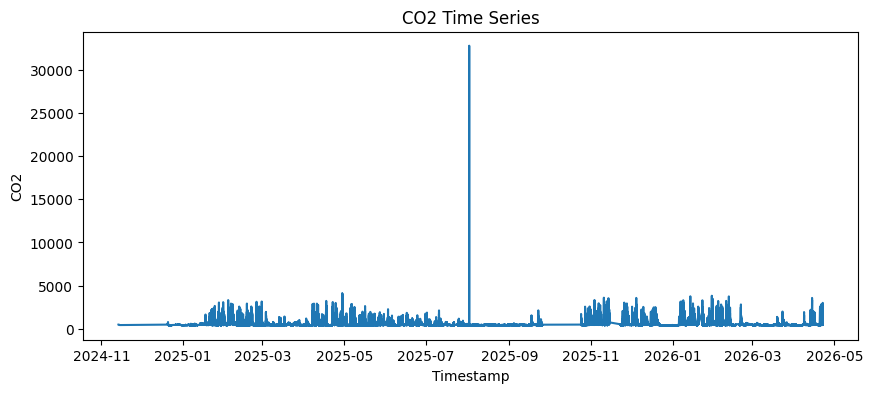

In [37]:
plt.figure(figsize=(10, 4))
plt.plot(df[TARGET])
plt.title("CO2 Time Series")
plt.xlabel("Timestamp")
plt.ylabel("CO2")
plt.show()

## 7. Optional EDA: Correlation Heatmap

This matches `plot_heatmap` from `dataLoad.py`.

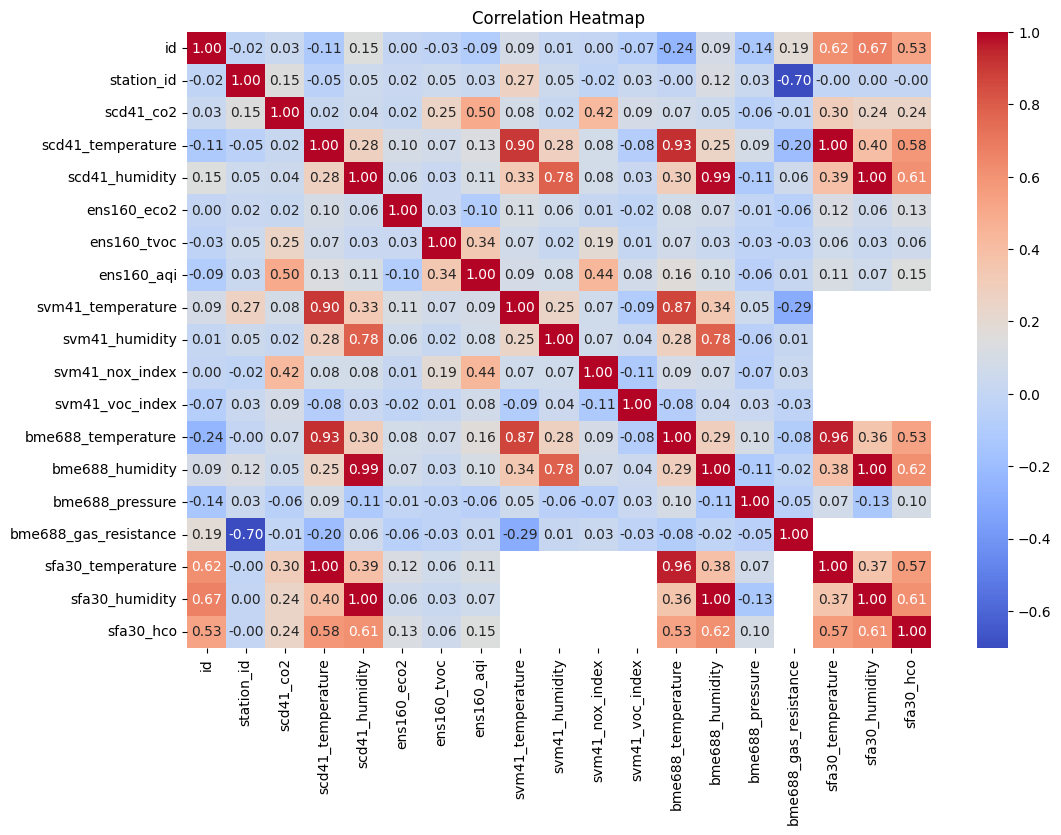

In [38]:
corr = df.select_dtypes(include=["float64", "int64"]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 8. Optional EDA: PCA Analysis

This follows `plot_pca_analysis`: select core numerical sensor features, fill missing values with time interpolation plus forward/backward fill, standardize, fit PCA, and plot cumulative explained variance.

========== PCA ANALYSIS ==========
Explained Variance Ratio:
[0.25181935 0.19757189 0.18862874 0.15373756 0.10822613 0.10001632]

Cumulative Variance:
[0.25181935 0.44939124 0.63801998 0.79175755 0.89998368 1.        ]


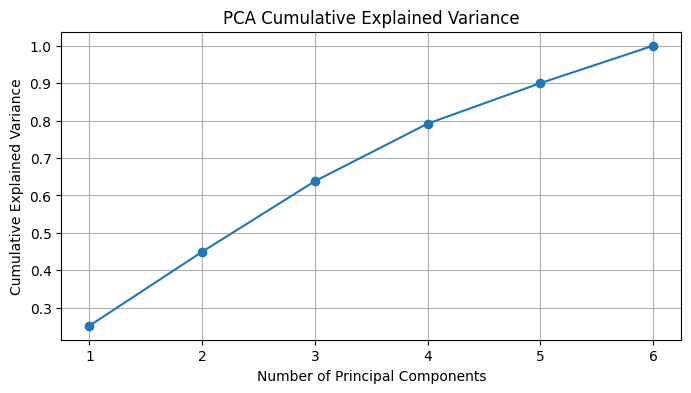

In [39]:
numerical_df = df[PCA_FEATURES].copy()
numerical_df = (
    numerical_df
    .interpolate(method="time")
    .ffill()
    .bfill()
    .dropna()
)

standard_scaler = StandardScaler()
scaled_pca_data = standard_scaler.fit_transform(numerical_df)

pca = PCA()
pca.fit(scaled_pca_data)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("========== PCA ANALYSIS ==========")
print("Explained Variance Ratio:")
print(explained_variance)
print("\nCumulative Variance:")
print(cumulative_variance)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.grid(True)
plt.show()

## 9. Add Time Features

This is the exact feature engineering from `add_time_features`. Hour and day of week are encoded cyclically with sine/cosine, and weekends are marked with a binary flag.

In [40]:
def add_time_features(input_df):
    output_df = input_df.copy()

    hour = output_df.index.hour
    dayofweek = output_df.index.dayofweek

    output_df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    output_df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    output_df["dayofweek_sin"] = np.sin(2 * np.pi * dayofweek / 7)
    output_df["dayofweek_cos"] = np.cos(2 * np.pi * dayofweek / 7)
    output_df["is_weekend"] = (dayofweek >= 5).astype(int)

    return output_df

df_with_time = add_time_features(df)
df_with_time[BASE_FEATURES + [STATION_COLUMN]].head()

,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
timestamp,,,,,,,,,,,,,
2024-11-13 16:57:56,1,32,NaN,NaN,22.951857,36.897277,488.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
2024-11-13 16:58:57,1,30,NaN,NaN,22.335011,38.185119,485.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
2024-11-13 16:59:59,1,43,NaN,NaN,22.353704,38.400268,477.0,-0.866025,-0.500000,0.974928,-0.222521,0,1
2024-11-13 17:01:03,1,26,NaN,NaN,22.417792,38.269042,474.0,-0.965926,-0.258819,0.974928,-0.222521,0,1
2024-11-13 17:02:05,1,31,NaN,NaN,22.556649,37.971496,473.0,-0.965926,-0.258819,0.974928,-0.222521,0,1


## 10. Select Model Features and Resample by Station

This is the key `preprocess_data` logic. After time features are added, the model keeps only `BASE_FEATURES` and `station_id`, then resamples each station independently to 15-minute intervals using mean values.

In [41]:
print("========== PREPROCESSING ==========")
print("Raw dataset shape:", df.shape)
print("Stations available:", sorted(df[STATION_COLUMN].unique().tolist()))

model_df = df_with_time[BASE_FEATURES + [STATION_COLUMN]].copy()

print("\nSelected features:")
print(BASE_FEATURES)
print("\nAfter feature selection:", model_df.shape)

model_df = (
    model_df
    .groupby(STATION_COLUMN)
    .resample("15min")
    .mean()
    .drop(columns=STATION_COLUMN, errors="ignore")
    .reset_index(level=0)
)

model_df = model_df[BASE_FEATURES + [STATION_COLUMN]]

print("\nAfter resampling:", model_df.shape)
model_df.head()

========== PREPROCESSING ==========
Raw dataset shape: (1924653, 20)
Stations available: [1, 2, 3, 4, 5, 6]

Selected features:
['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend']

After feature selection: (1924653, 13)

After resampling: (186894, 13)


C:\Users\Kenil Dhorajiya\AppData\Local\Temp\ipykernel_22880\1860017986.py:15: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .mean()


,ens160_aqi,ens160_tvoc,bme688_gas_resistance,bme688_pressure,scd41_temperature,scd41_humidity,scd41_co2,hour_sin,hour_cos,dayofweek_sin,dayofweek_cos,is_weekend,station_id
timestamp,,,,,,,,,,,,,
2024-11-13 16:45:00,1.0,35.000000,NaN,NaN,22.546857,37.827555,483.333333,-0.866025,-0.500000,0.974928,-0.222521,0.0,1
2024-11-13 17:00:00,1.0,26.857143,NaN,NaN,22.746242,37.604195,472.285714,-0.965926,-0.258819,0.974928,-0.222521,0.0,1
2024-11-13 17:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2024-11-13 17:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2024-11-13 17:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1


## 11. Cross-Station Train, Validation, and Test Split

The active code uses a cross-station experiment, not a chronological split. It trains on station 3, validates on station 4, and tests on station 5.

The old chronological station-wise split exists only as commented code in the source, so it is kept below as a reference cell and not used for training.

In [42]:
TRAIN_STATION = 3
VAL_STATION = 4
TEST_STATION = 5

train_df = model_df[model_df[STATION_COLUMN] == TRAIN_STATION].sort_index()
val_df = model_df[model_df[STATION_COLUMN] == VAL_STATION].sort_index()
test_df = model_df[model_df[STATION_COLUMN] == TEST_STATION].sort_index()

print("========== CROSS-STATION SPLIT ==========")
print(f"Training Station: {TRAIN_STATION}")
print("Train shape:", train_df.shape)
print(f"\nValidation Station: {VAL_STATION}")
print("Validation shape:", val_df.shape)
print(f"\nTesting Station: {TEST_STATION}")
print("Test shape:", test_df.shape)

train_parts = [train_df]
val_parts = [val_df]
test_parts = [test_df]

========== CROSS-STATION SPLIT ==========
Training Station: 3
Train shape: (44163, 13)

Validation Station: 4
Validation shape: (43755, 13)

Testing Station: 5
Test shape: (29203, 13)


### Reference Only: Old Chronological Split

This was commented out in the original file. It is included here so the notebook does not lose that idea, but the active model below uses the cross-station split above.

In [43]:
# Reference only: not used by the active CNN-LSTM pipeline.
#
# train_parts, val_parts, test_parts = [], [], []
# for station_id, station_df in model_df.groupby(STATION_COLUMN):
#     station_df = station_df.sort_index()
#     train_end = int(len(station_df) * 0.70)
#     val_end = int(len(station_df) * 0.85)
#
#     station_train_df = station_df.iloc[:train_end]
#     station_val_df = station_df.iloc[train_end:val_end]
#     station_test_df = station_df.iloc[val_end:]
#
#     train_parts.append(station_train_df)
#     val_parts.append(station_val_df)
#     test_parts.append(station_test_df)

## 12. Fill Missing Values

This follows `fill_missing_parts`. Rows with missing target values are removed first. Other input features are forward-filled and backward-filled inside each split part, and any remaining missing rows are dropped.

In [44]:
def fill_missing_parts(parts):
    cleaned_parts = []
    input_features = [col for col in BASE_FEATURES if col != TARGET]

    for part in parts:
        part = part.copy()

        print("\nMissing values before interpolation:")
        print(part.isna().sum().sum())

        part = part.dropna(subset=[TARGET])
        part[input_features] = part[input_features].ffill().bfill()
        part = part.dropna()

        print("Missing values after interpolation:")
        print(part.isna().sum().sum())

        if len(part) > 0:
            cleaned_parts.append(part)

    return cleaned_parts

train_parts = fill_missing_parts(train_parts)
val_parts = fill_missing_parts(val_parts)
test_parts = fill_missing_parts(test_parts)

[len(p) for p in train_parts], [len(p) for p in val_parts], [len(p) for p in test_parts]


Missing values before interpolation:
226968
Missing values after interpolation:
0

Missing values before interpolation:
57672
Missing values after interpolation:
0

Missing values before interpolation:
132648
Missing values after interpolation:
0


([25249], [38949], [18149])

## 13. Add One-Hot Station Features

The original model keeps `station_id` out of the numeric model array and instead creates one-hot station columns for every station found after preprocessing.

In [45]:
station_ids = sorted(model_df[STATION_COLUMN].unique().tolist())
station_features = [f"station_{sid}" for sid in station_ids]
model_features = BASE_FEATURES + station_features

def build_model_parts(parts, station_ids):
    station_features = [f"station_{sid}" for sid in station_ids]
    model_features = BASE_FEATURES + station_features
    model_parts = []

    for part in parts:
        part = part.copy()

        for sid in station_ids:
            part[f"station_{sid}"] = (part[STATION_COLUMN] == sid).astype(int)

        values = part[model_features].values

        if len(values) > 0:
            model_parts.append(values)

    return model_parts, model_features

train_arrays, model_features = build_model_parts(train_parts, station_ids)
val_arrays, _ = build_model_parts(val_parts, station_ids)
test_arrays, _ = build_model_parts(test_parts, station_ids)

print("Station IDs:", station_ids)
print("Model features:", model_features)
print("Number of model features:", len(model_features))

Station IDs: [1, 2, 3, 4, 5, 6]
Model features: ['ens160_aqi', 'ens160_tvoc', 'bme688_gas_resistance', 'bme688_pressure', 'scd41_temperature', 'scd41_humidity', 'scd41_co2', 'hour_sin', 'hour_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_weekend', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6']
Number of model features: 18


## 14. Scale Data with Training Data Only

This is an important leakage-prevention step. The `MinMaxScaler` is fit only on the training arrays, then applied to train, validation, and test arrays.

In [46]:
scaler = MinMaxScaler()
scaler.fit(np.vstack(train_arrays))

print("Scaler fitted ONLY on training data.")

train_scaled = [scaler.transform(p) for p in train_arrays if len(p) > 0]
val_scaled = [scaler.transform(p) for p in val_arrays if len(p) > 0]
test_scaled = [scaler.transform(p) for p in test_arrays if len(p) > 0]

train_scaled[0].shape, val_scaled[0].shape, test_scaled[0].shape

Scaler fitted ONLY on training data.


((25249, 18), (38949, 18), (18149, 18))

## 15. Create Multi-Step Forecasting Sequences

Each input sample uses `INPUT_SEQ_LENGTH=24` time steps. Each target contains the next `OUTPUT_SEQ_LENGTH=6` CO2 values. The target index is located inside `model_features`, so the target remains correct even after station one-hot features are added.

In [47]:
def create_sequences(data_parts, model_features, input_seq_length=24, output_seq_length=6):
    X, y = [], []
    target_index = model_features.index(TARGET)

    for data in data_parts:
        print("\nOriginal data shape before sequencing:", data.shape)

        required_length = input_seq_length + output_seq_length

        if len(data) <= required_length:
            print("\nSkipping sequence generation:")
            print(f"Available rows: {len(data)}")
            print(f"Required minimum rows: {required_length + 1}")
            continue

        for i in range(len(data) - input_seq_length - output_seq_length):
            X.append(data[i:i + input_seq_length])
            y.append(data[i + input_seq_length:i + input_seq_length + output_seq_length, target_index])

    X = np.array(X)
    y = np.array(y)

    print("Sequence input shape:", X.shape)
    print("Sequence target shape:", y.shape)

    if len(X) == 0:
        raise ValueError(
            "\nNo CNN-LSTM sequences were created.\n"
            "Possible reasons:\n"
            "- selected station has too few rows\n"
            "- too many missing values removed\n"
            "- input/output sequence lengths are too large\n"
            "- train/validation/test split is too small"
        )

    return X, y

X_train, y_train = create_sequences(train_scaled, model_features, INPUT_SEQ_LENGTH, OUTPUT_SEQ_LENGTH)
X_val, y_val = create_sequences(val_scaled, model_features, INPUT_SEQ_LENGTH, OUTPUT_SEQ_LENGTH)
X_test, y_test = create_sequences(test_scaled, model_features, INPUT_SEQ_LENGTH, OUTPUT_SEQ_LENGTH)


Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)


## 16. Build PyTorch DataLoaders

The training loader shuffles batches. Validation and test loaders keep order stable.

In [48]:
def create_loader(X, y, batch_size=32, shuffle=False):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tensor, y_tensor),
        batch_size=batch_size,
        shuffle=shuffle,
    )

    sample_X, sample_y = next(iter(loader))

    print("\n========== DATALOADER ==========")
    print("Batch input shape:", sample_X.shape)
    print("Batch target shape:", sample_y.shape)

    return loader

train_loader = create_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader = create_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = create_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

input_size = X_train.shape[2]
input_size


========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])


18

## 17. Define the CNN-LSTM Model

This is the model class from the source file. The input is shaped as `batch, time, features`. The model permutes it for 1D convolutions, applies two convolution layers with ReLU and dropout, permutes back for the LSTM, takes the final LSTM time step, and predicts all future CO2 steps with one linear layer.

In [49]:
class CNNLSTMModel(nn.Module):
    def __init__(self, input_size, output_seq_length=6, hidden_size=64, num_layers=2, dropout=0.3):
        super().__init__()

        self.conv1 = nn.Conv1d(input_size, 128, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        self.lstm = nn.LSTM(
            128,
            hidden_size,
            num_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(hidden_size, output_seq_length)

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.dropout(self.relu(self.conv1(x)))
        x = self.dropout(self.relu(self.conv2(x)))
        x = x.permute(0, 2, 1)

        output, _ = self.lstm(x)
        output = output[:, -1, :]

        return self.fc(output)

model = CNNLSTMModel(input_size=input_size, output_seq_length=OUTPUT_SEQ_LENGTH)
model

CNNLSTMModel(
  (conv1): Conv1d(18, 128, kernel_size=(5,), stride=(1,), padding=(2,))
  (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(128, 64, num_layers=2, batch_first=True)
  (fc): Linear(in_features=64, out_features=6, bias=True)
)

## 18. Sanity Check One Forward Pass

Before training, check that one batch produces `OUTPUT_SEQ_LENGTH` predictions per sample.

In [50]:
sample_X, sample_y = next(iter(train_loader))
with torch.no_grad():
    sample_predictions = model(sample_X)

print("Sample input shape:", sample_X.shape)
print("Sample target shape:", sample_y.shape)
print("Sample prediction shape:", sample_predictions.shape)

Sample input shape: torch.Size([32, 24, 18])
Sample target shape: torch.Size([32, 6])
Sample prediction shape: torch.Size([32, 6])


## 19. Training Helpers

These cells keep the original loss and optimizer choices: MSE loss and Adam with learning rate `0.001`.

In [51]:
def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()

    return total_loss / len(loader)


def train_model(model, train_loader, val_loader, epochs=10):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss = train_loss / len(train_loader)
        val_loss = evaluate_loss(model, val_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch {epoch + 1}, "
            f"Train Loss: {train_loss:.6f}, "
            f"Val Loss: {val_loss:.6f}"
        )

    return model, train_losses, val_losses

## 20. Train the Model

Run this cell to train the CNN-LSTM. Increase `EPOCHS` in the configuration cell if you want a longer run.

In [52]:
model, train_losses, val_losses = train_model(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
)

Epoch 1, Train Loss: 0.004939, Val Loss: 0.004010
Epoch 2, Train Loss: 0.002863, Val Loss: 0.003622
Epoch 3, Train Loss: 0.002593, Val Loss: 0.003400
Epoch 4, Train Loss: 0.002455, Val Loss: 0.003538
Epoch 5, Train Loss: 0.002303, Val Loss: 0.003016
Epoch 6, Train Loss: 0.002217, Val Loss: 0.003229
Epoch 7, Train Loss: 0.002138, Val Loss: 0.002960
Epoch 8, Train Loss: 0.002038, Val Loss: 0.003140
Epoch 9, Train Loss: 0.002025, Val Loss: 0.003164
Epoch 10, Train Loss: 0.001967, Val Loss: 0.003478


## 21. Plot Training and Validation Loss

This is the notebook version of `plot_loss_curves`.

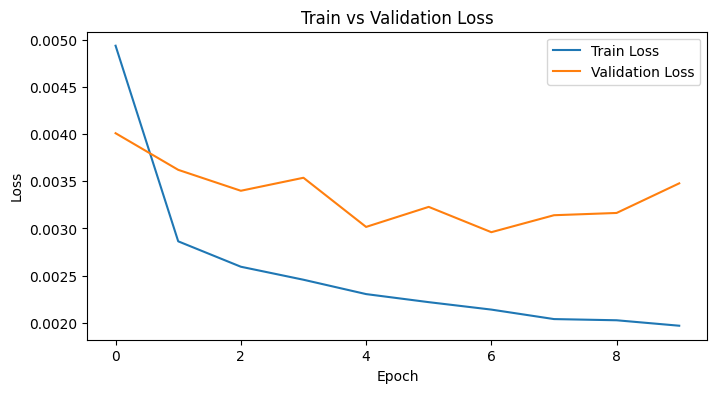

In [53]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train vs Validation Loss")
plt.legend()
plt.show()

# 22. Evaluate on the Test Station

This follows `evaluate_model`. The metrics are computed after flattening all forecast steps together, exactly like the source code.

In [54]:
def evaluate_model(model, test_loader):
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            predictions.extend(outputs.numpy())
            actuals.extend(y_batch.numpy())

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    mse = mean_squared_error(actuals.flatten(), predictions.flatten())
    mae = mean_absolute_error(actuals.flatten(), predictions.flatten())
    rmse = np.sqrt(mse)

    print("\n========== MODEL EVALUATION ==========")
    print("Overall MSE:", mse)
    print("Overall MAE:", mae)
    print("Overall RMSE:", rmse)

    return predictions, actuals, mse, mae, rmse

predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)


========== MODEL EVALUATION ==========
Overall MSE: 0.0022648663725703955
Overall MAE: 0.028263425454497337
Overall RMSE: 0.04759061223151469


## 23. Optional Per-Step Forecast Metrics

The per-step metric block was commented out in the source. It is useful in a notebook because this is a multi-step forecast, so each forecast horizon can behave differently.

In [55]:
for step in range(actuals.shape[1]):
    step_mse = mean_squared_error(actuals[:, step], predictions[:, step])
    step_mae = mean_absolute_error(actuals[:, step], predictions[:, step])
    step_rmse = np.sqrt(step_mse)

    print(f"Forecast Step {step + 1}")
    print(f"MSE: {step_mse:.6f}")
    print(f"MAE: {step_mae:.6f}")
    print(f"RMSE: {step_rmse:.6f}\n")

Forecast Step 1
MSE: 0.001624
MAE: 0.023019
RMSE: 0.040299

Forecast Step 2
MSE: 0.002053
MAE: 0.028375
RMSE: 0.045312

Forecast Step 3
MSE: 0.002116
MAE: 0.026551
RMSE: 0.046005

Forecast Step 4
MSE: 0.002353
MAE: 0.028169
RMSE: 0.048503

Forecast Step 5
MSE: 0.002625
MAE: 0.031240
RMSE: 0.051232

Forecast Step 6
MSE: 0.002818
MAE: 0.032226
RMSE: 0.053086



## 24. Plot Actual vs Predicted CO2

This matches `plot_predictions`. Change `FORECAST_STEP_TO_PLOT` from 1 to 6 to inspect different forecast horizons.

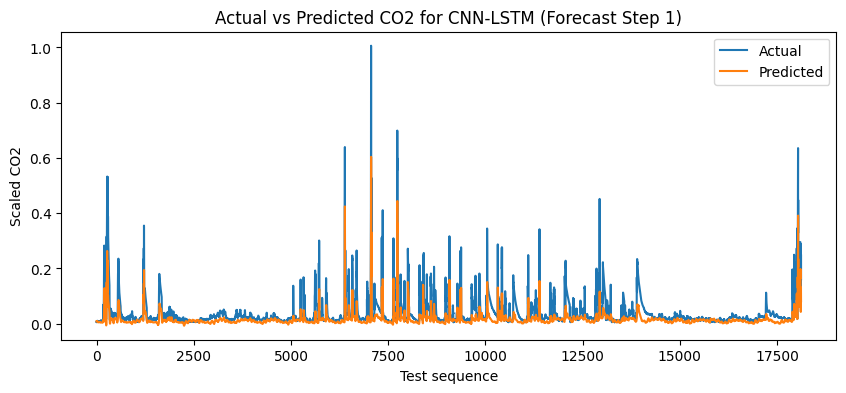

In [56]:
FORECAST_STEP_TO_PLOT = 1
step_index = FORECAST_STEP_TO_PLOT - 1

plt.figure(figsize=(10, 4))
plt.plot(actuals[:, step_index], label="Actual")
plt.plot(predictions[:, step_index], label="Predicted")
plt.legend()
plt.title(f"Actual vs Predicted CO2 for CNN-LSTM (Forecast Step {FORECAST_STEP_TO_PLOT})")
plt.xlabel("Test sequence")
plt.ylabel("Scaled CO2")
plt.show()

## 25. Collect Results

This mirrors the dictionary returned by `run_cnn_lstm_model`.

In [57]:
cnn_results = {
    "model": model,
    "predictions": predictions,
    "actuals": actuals,
    "mse": mse,
    "mae": mae,
    "rmse": rmse,
}

cnn_results.keys()

dict_keys(['model', 'predictions', 'actuals', 'mse', 'mae', 'rmse'])

## 26. Optional: Save the Trained Model

The original script returns the model but does not save it. This optional cell saves the trained PyTorch weights if you want to reuse them later.

In [58]:
# Optional save. Uncomment when needed.
# MODEL_OUTPUT_PATH = os.path.join(PROJECT_DIR, "notebooks", "cnn_lstm_model.pt")
# torch.save(model.state_dict(), MODEL_OUTPUT_PATH)
# MODEL_OUTPUT_PATH

## 27. Compact Function Version

After running the notebook step by step, this helper gives you a compact function similar to the original `run_pipeline`, while still using the notebook-defined pieces above.

In [59]:
def run_notebook_pipeline(raw_df, epochs=10, input_seq_length=24, output_seq_length=6, batch_size=32):
    prepared = add_time_features(raw_df)
    prepared = prepared[BASE_FEATURES + [STATION_COLUMN]]
    prepared = (
        prepared
        .groupby(STATION_COLUMN)
        .resample("15min")
        .mean()
        .drop(columns=STATION_COLUMN, errors="ignore")
        .reset_index(level=0)
    )
    prepared = prepared[BASE_FEATURES + [STATION_COLUMN]]

    station_ids = sorted(prepared[STATION_COLUMN].unique().tolist())

    train_parts = [prepared[prepared[STATION_COLUMN] == TRAIN_STATION].sort_index()]
    val_parts = [prepared[prepared[STATION_COLUMN] == VAL_STATION].sort_index()]
    test_parts = [prepared[prepared[STATION_COLUMN] == TEST_STATION].sort_index()]

    train_parts = fill_missing_parts(train_parts)
    val_parts = fill_missing_parts(val_parts)
    test_parts = fill_missing_parts(test_parts)

    train_arrays, model_features = build_model_parts(train_parts, station_ids)
    val_arrays, _ = build_model_parts(val_parts, station_ids)
    test_arrays, _ = build_model_parts(test_parts, station_ids)

    scaler = MinMaxScaler()
    scaler.fit(np.vstack(train_arrays))

    train_scaled = [scaler.transform(p) for p in train_arrays if len(p) > 0]
    val_scaled = [scaler.transform(p) for p in val_arrays if len(p) > 0]
    test_scaled = [scaler.transform(p) for p in test_arrays if len(p) > 0]

    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)

    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)

    model = CNNLSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)

    return {
        "model": model,
        "predictions": predictions,
        "actuals": actuals,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "train_losses": train_losses,
        "val_losses": val_losses,
    }

## 28. This Code Below Is Show The All Results Here



Starting automation run... Plots will appear one-by-one immediately after training!

TRAINING NOW: Target = ens160_aqi | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])
Epoch 1, Train Loss: 0.001345, Val Loss: 0.004848
Epoch 2, Train Loss: 0.000635, Val Loss: 0.004222
Epoch 3, Train Loss: 0.000526, Val 

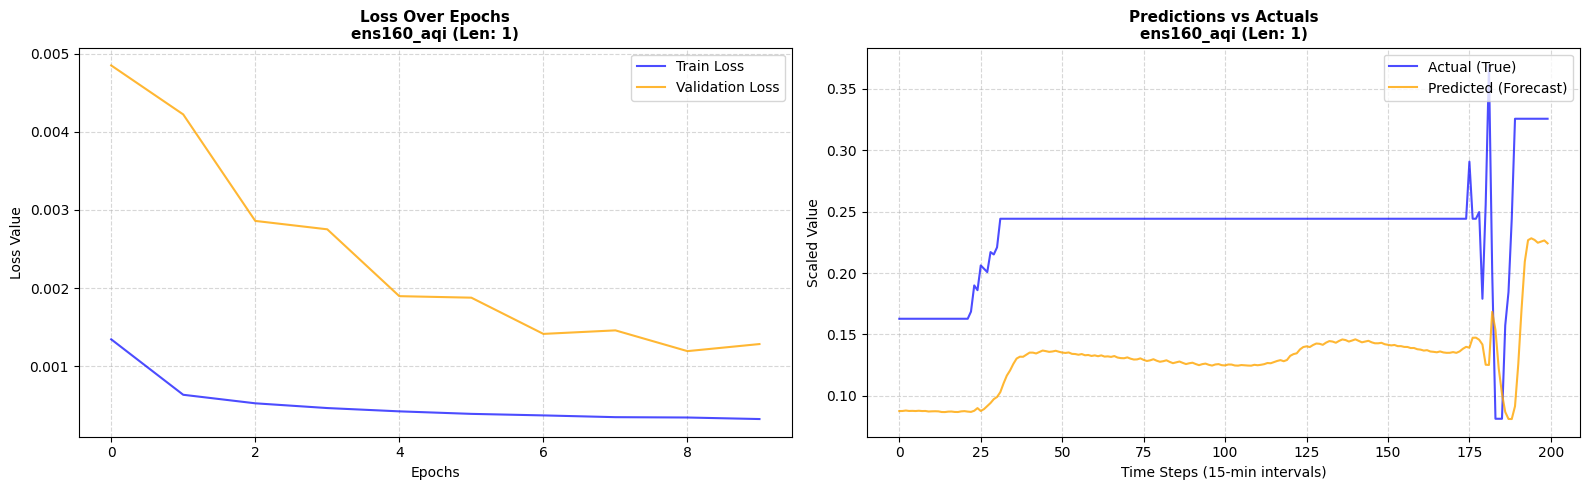

Finished displaying graphs for ens160_aqi (len=1)

TRAINING NOW: Target = ens160_aqi | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])
Epoch 1, Train Loss: 0.002955, Val Loss: 0.002281
Epoch 2, Train Loss: 0.000895, Val Loss: 0.001801
Epoch 3, Train Loss: 0.000804, Val Loss: 0.002512
Epoch 4, Train Loss

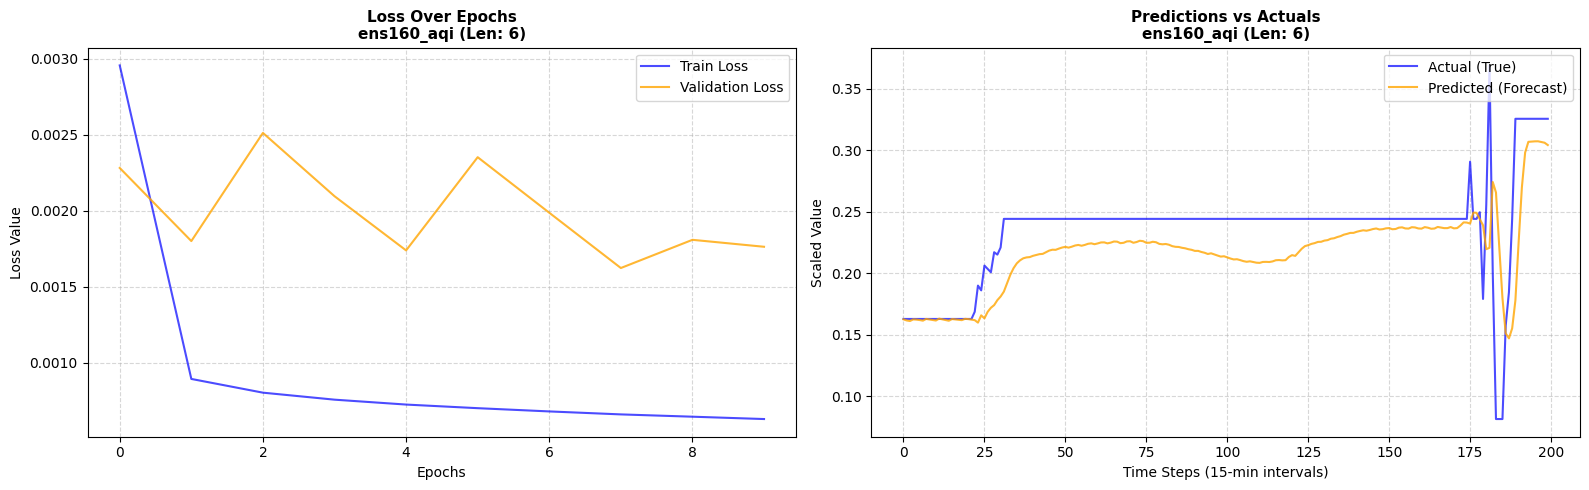

Finished displaying graphs for ens160_aqi (len=6)

TRAINING NOW: Target = ens160_aqi | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])
Epoch 1, Train Loss: 0.002749, Val Loss: 0.003123
Epoch 2, Train Loss: 0.001102, Val Loss: 0.002344
Epoch 3, Train Loss: 0.001013, Val Loss: 0.001496
Epoch 4, Tra

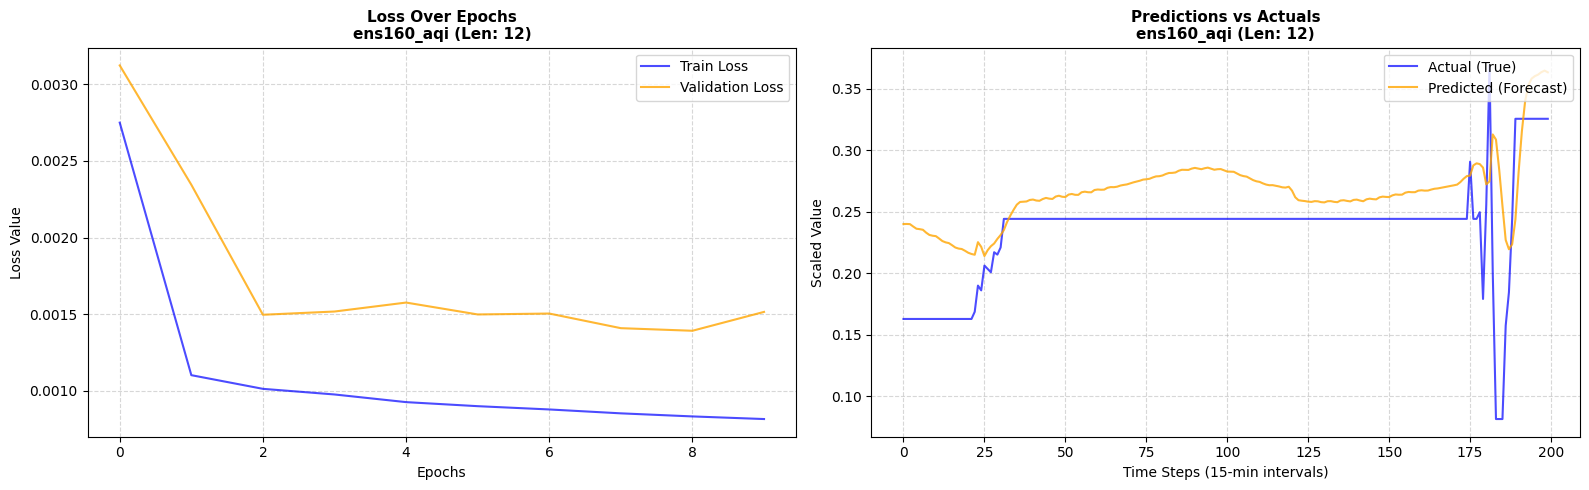

Finished displaying graphs for ens160_aqi (len=12)

TRAINING NOW: Target = ens160_tvoc | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])
Epoch 1, Train Loss: 0.001070, Val Loss: 0.001011
Epoch 2, Train Loss: 0.000519, Val Loss: 0.001071
Epoch 3, Train Loss: 0.000471, Val Loss: 0.000752
Epoch 4, Train Lo

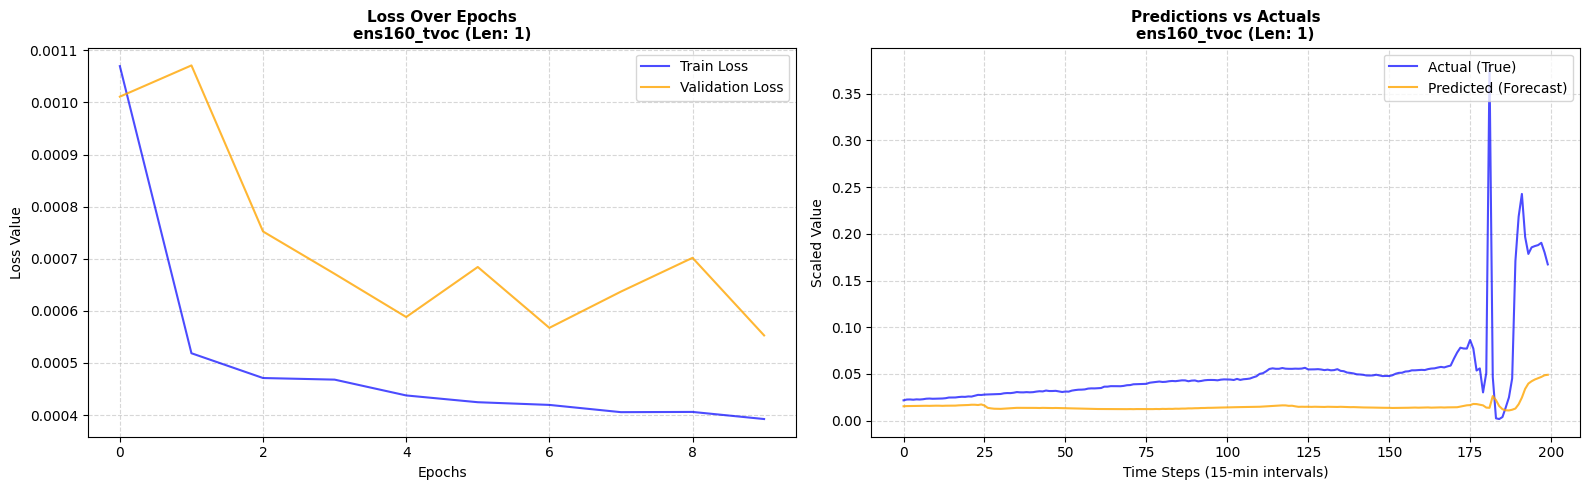

Finished displaying graphs for ens160_tvoc (len=1)

TRAINING NOW: Target = ens160_tvoc | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])
Epoch 1, Train Loss: 0.001428, Val Loss: 0.000931
Epoch 2, Train Loss: 0.000626, Val Loss: 0.000842
Epoch 3, Train Loss: 0.000579, Val Loss: 0.000789
Epoch 4, Train Lo

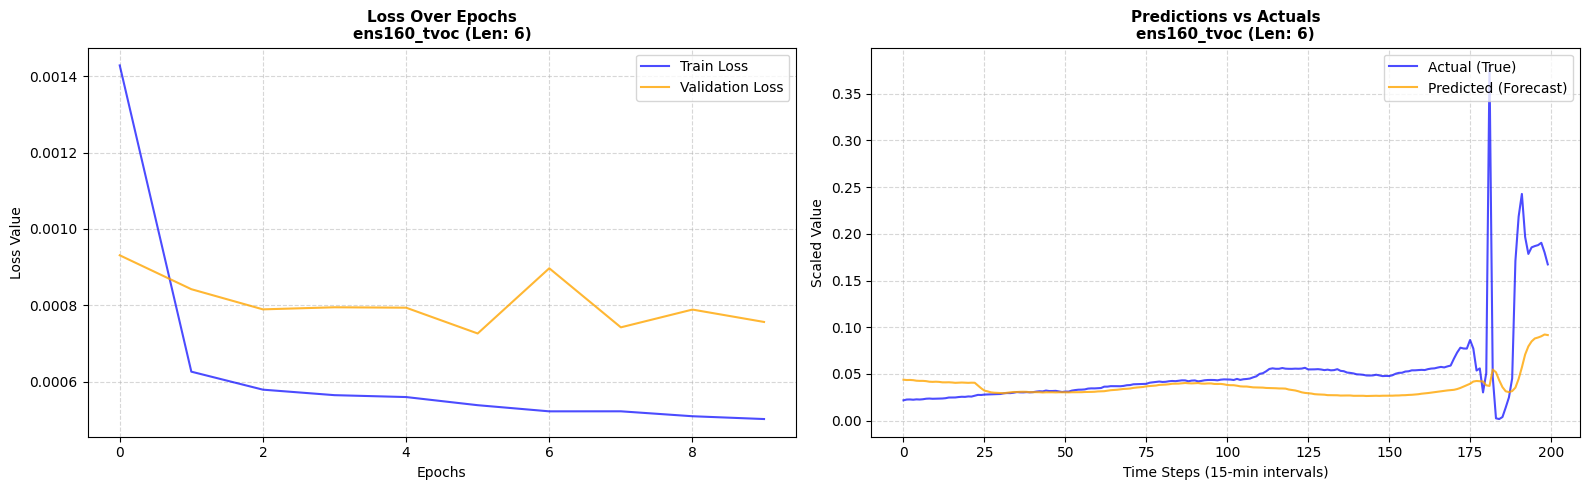

Finished displaying graphs for ens160_tvoc (len=6)

TRAINING NOW: Target = ens160_tvoc | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])
Epoch 1, Train Loss: 0.001177, Val Loss: 0.000979
Epoch 2, Train Loss: 0.000686, Val Loss: 0.001014
Epoch 3, Train Loss: 0.000657, Val Loss: 0.000933
Epoch 4, T

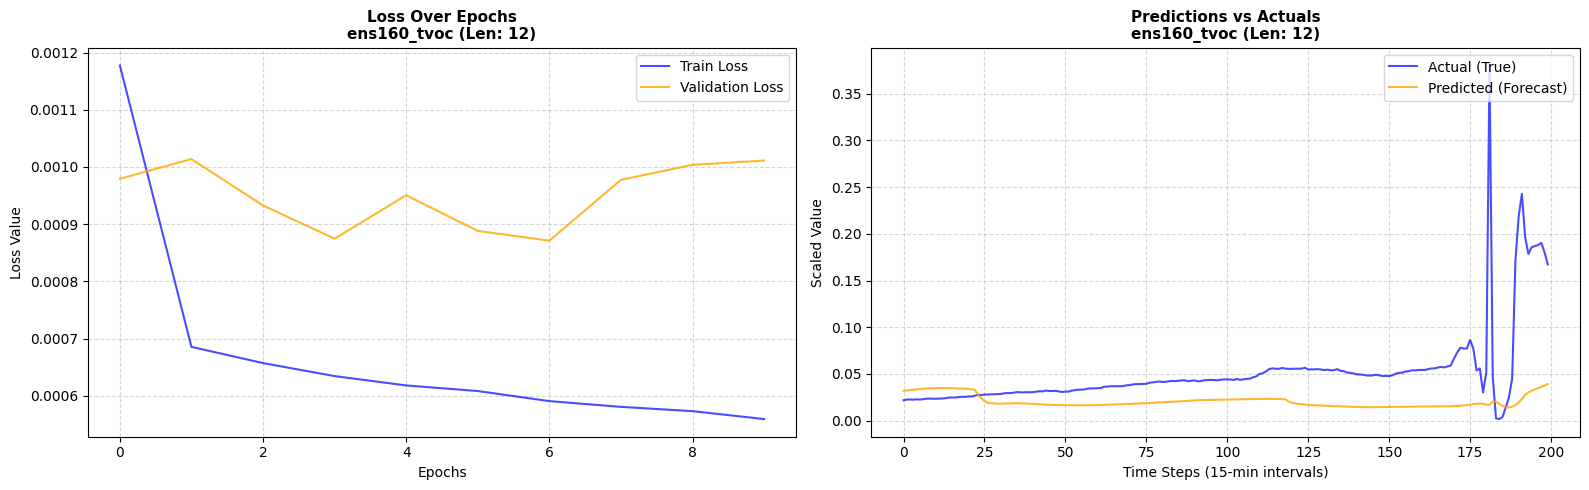

Finished displaying graphs for ens160_tvoc (len=12)

TRAINING NOW: Target = scd41_temperature | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])
Epoch 1, Train Loss: 0.013537, Val Loss: 0.007255
Epoch 2, Train Loss: 0.001643, Val Loss: 0.003039
Epoch 3, Train Loss: 0.001347, Val Loss: 0.003748
Epoch 4, T

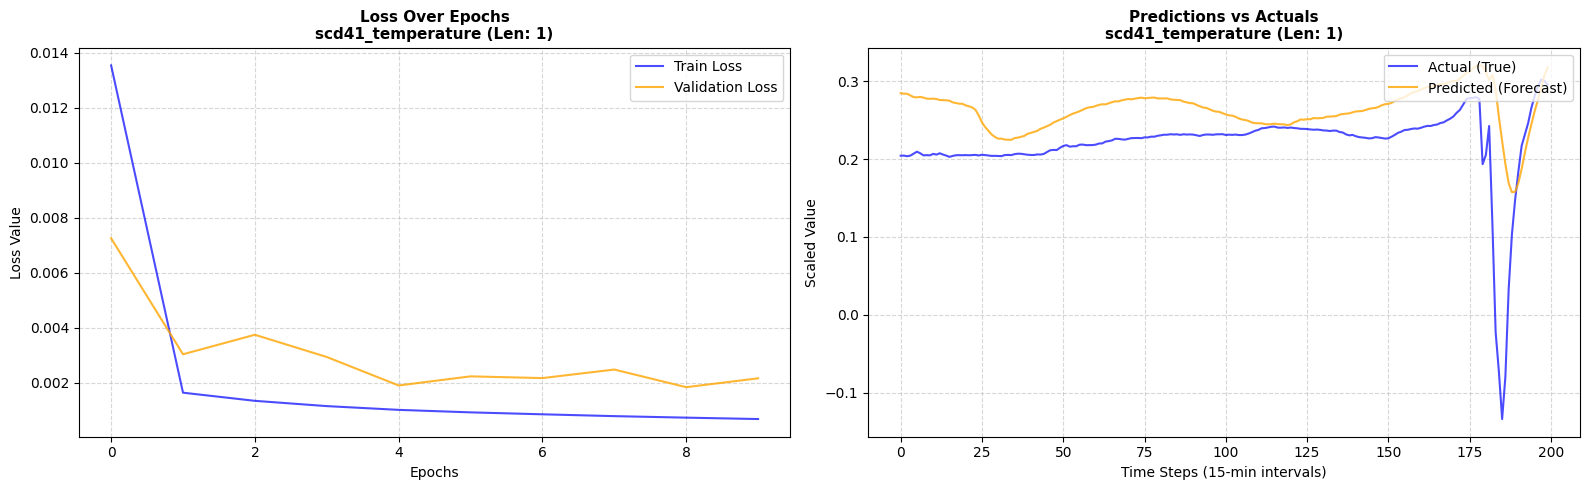

Finished displaying graphs for scd41_temperature (len=1)

TRAINING NOW: Target = scd41_temperature | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])
Epoch 1, Train Loss: 0.028225, Val Loss: 0.012714
Epoch 2, Train Loss: 0.002438, Val Loss: 0.015557
Epoch 3, Train Loss: 0.002037, Val Loss: 0.011527
Epoch

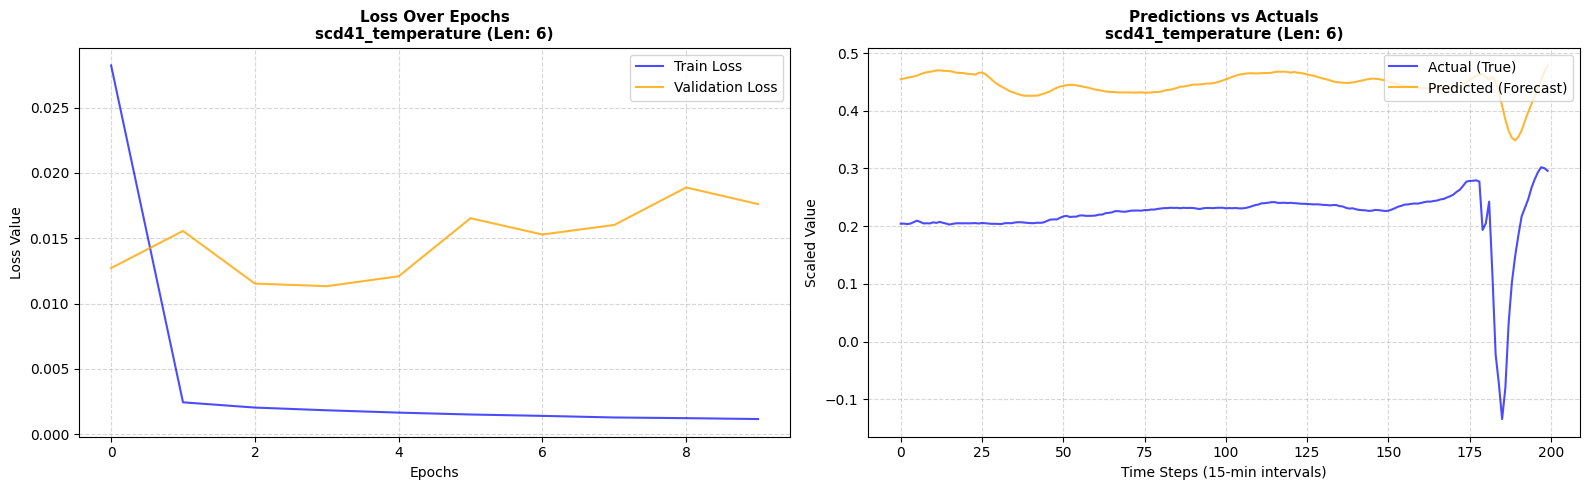

Finished displaying graphs for scd41_temperature (len=6)

TRAINING NOW: Target = scd41_temperature | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])
Epoch 1, Train Loss: 0.034061, Val Loss: 0.010155
Epoch 2, Train Loss: 0.003251, Val Loss: 0.010697
Epoch 3, Train Loss: 0.002635, Val Loss: 0.01180

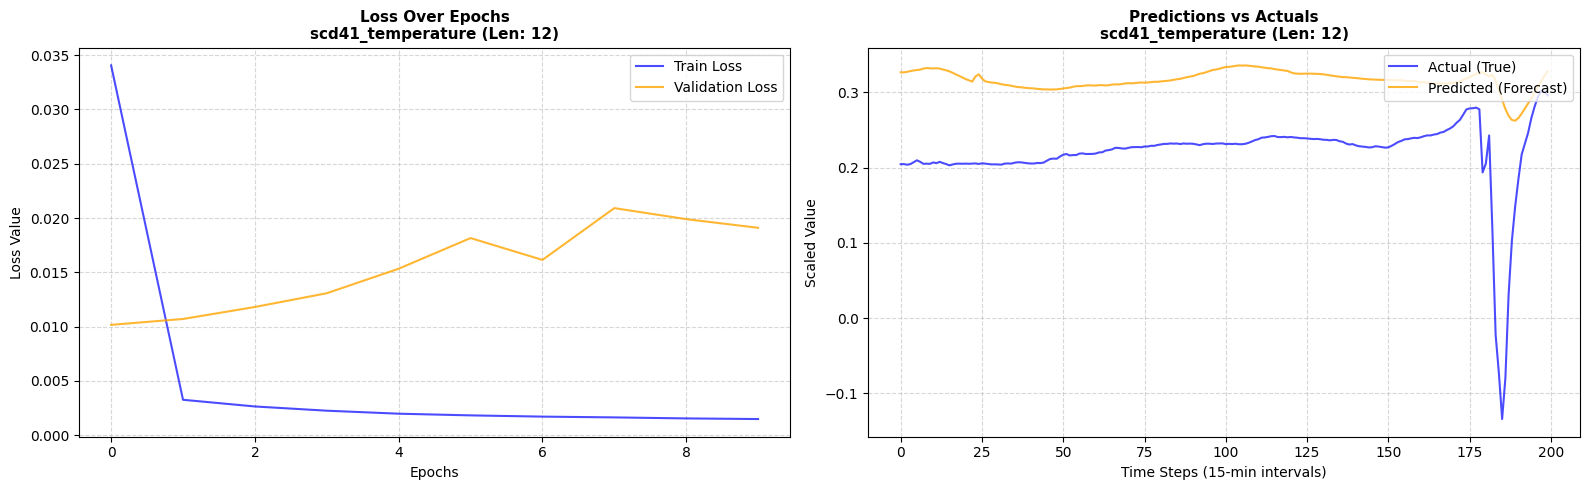

Finished displaying graphs for scd41_temperature (len=12)

TRAINING NOW: Target = scd41_humidity | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])
Epoch 1, Train Loss: 0.014432, Val Loss: 0.003012
Epoch 2, Train Loss: 0.001208, Val Loss: 0.003093
Epoch 3, Train Loss: 0.000962, Val Loss: 0.002691
Epoch 4

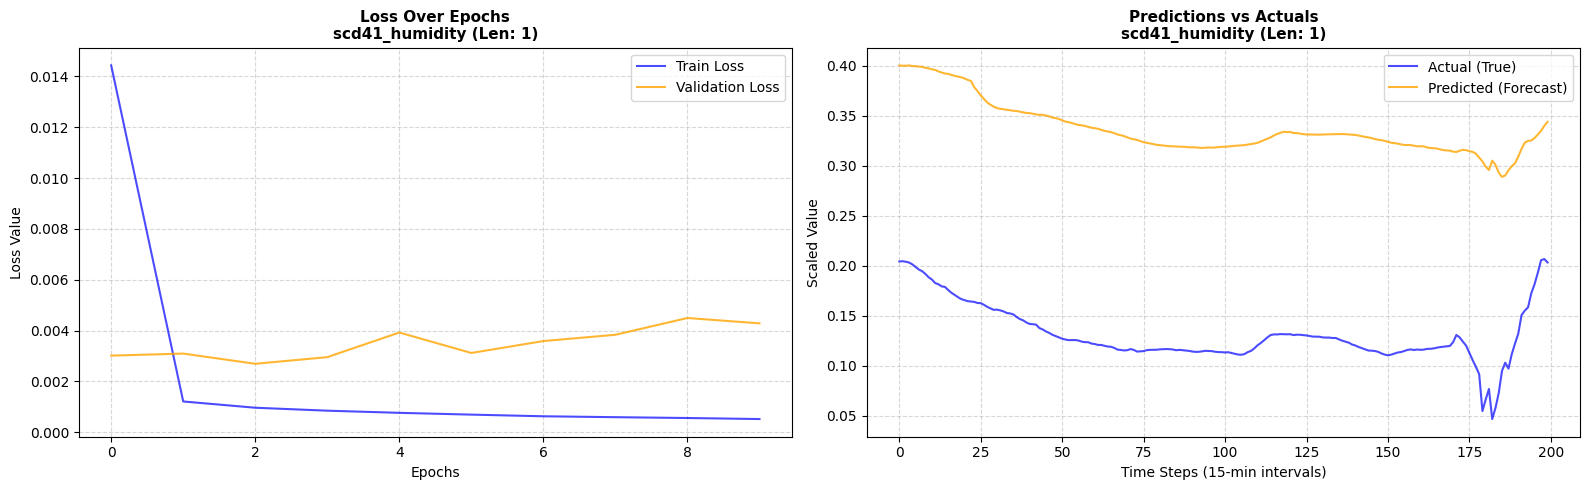

Finished displaying graphs for scd41_humidity (len=1)

TRAINING NOW: Target = scd41_humidity | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])
Epoch 1, Train Loss: 0.014029, Val Loss: 0.012541
Epoch 2, Train Loss: 0.001575, Val Loss: 0.010465
Epoch 3, Train Loss: 0.001345, Val Loss: 0.011372
Epoch 4, Tr

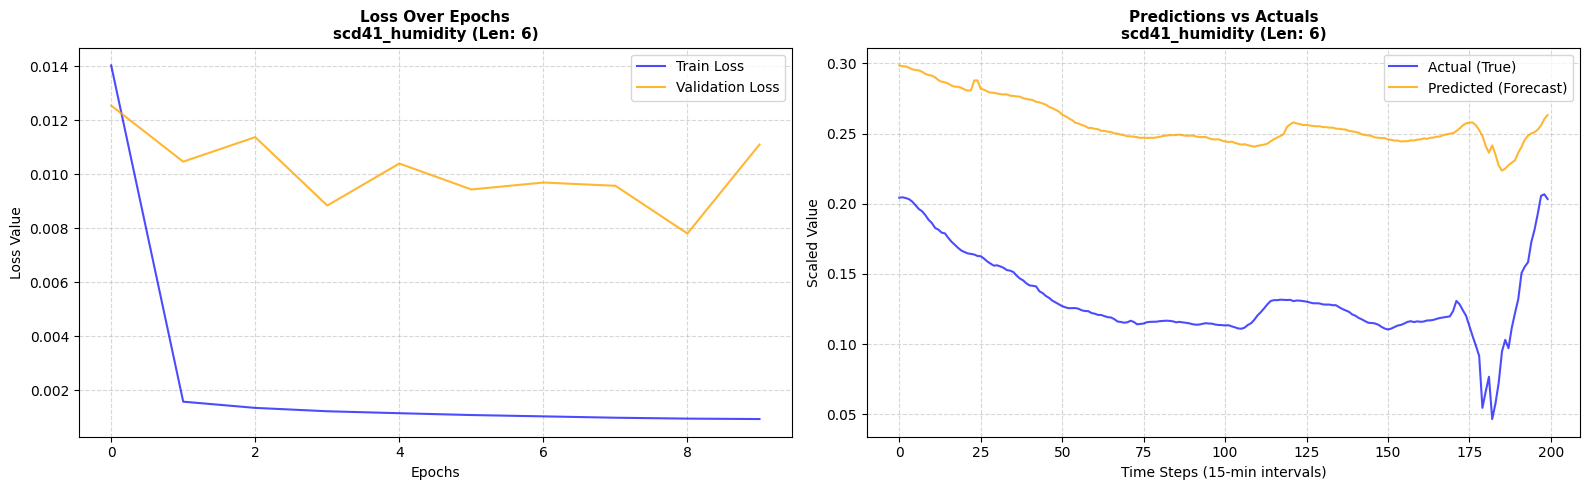

Finished displaying graphs for scd41_humidity (len=6)

TRAINING NOW: Target = scd41_humidity | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])
Epoch 1, Train Loss: 0.018938, Val Loss: 0.006545
Epoch 2, Train Loss: 0.002031, Val Loss: 0.007721
Epoch 3, Train Loss: 0.001753, Val Loss: 0.009278
Epoc

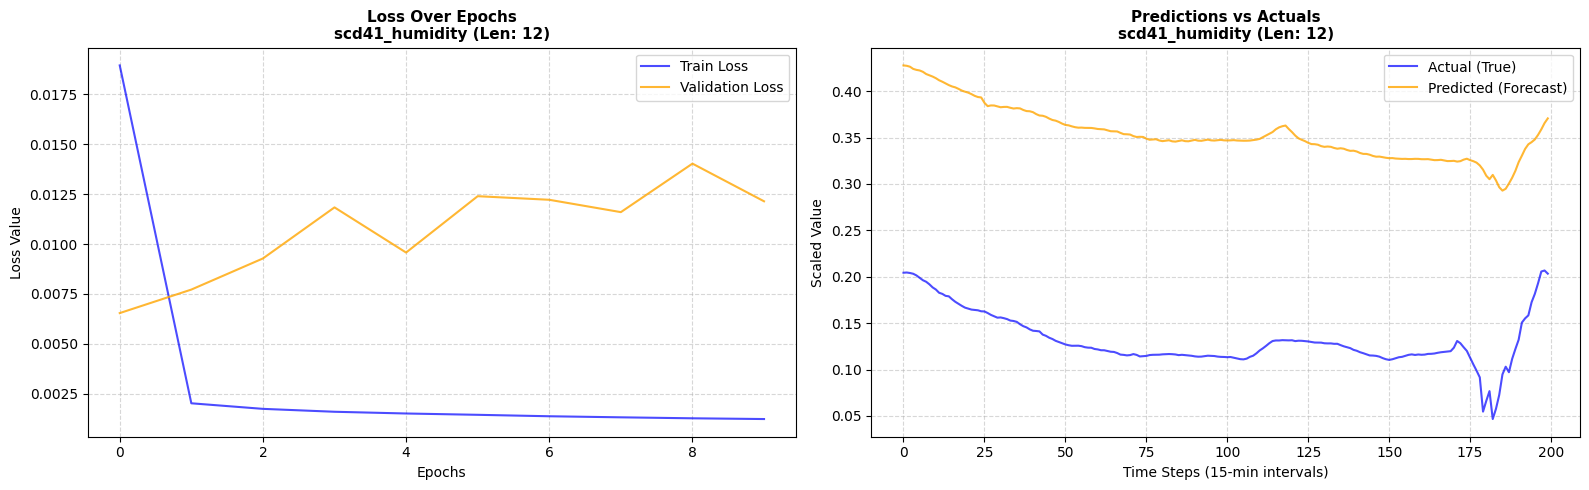

Finished displaying graphs for scd41_humidity (len=12)

TRAINING NOW: Target = scd41_co2 | Output Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])
Epoch 1, Train Loss: 0.003489, Val Loss: 0.005816
Epoch 2, Train Loss: 0.001640, Val Loss: 0.006090
Epoch 3, Train Loss: 0.001252, Val Loss: 0.002938
Epoch 4, Train 

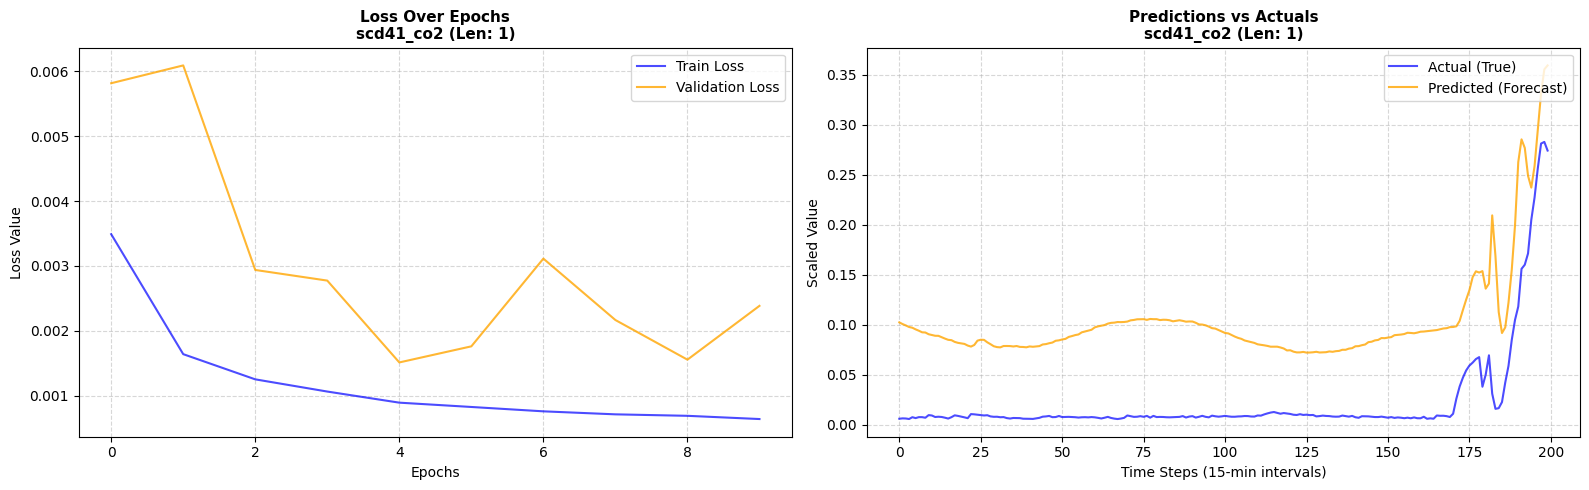

Finished displaying graphs for scd41_co2 (len=1)

TRAINING NOW: Target = scd41_co2 | Output Length = 6

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25219, 24, 18)
Sequence target shape: (25219, 6)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38919, 24, 18)
Sequence target shape: (38919, 6)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18119, 24, 18)
Sequence target shape: (18119, 6)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 6])
Epoch 1, Train Loss: 0.004691, Val Loss: 0.004756
Epoch 2, Train Loss: 0.002789, Val Loss: 0.003651
Epoch 3, Train Loss: 0.002545, Val Loss: 0.004021
Epoch 4, Train Loss: 

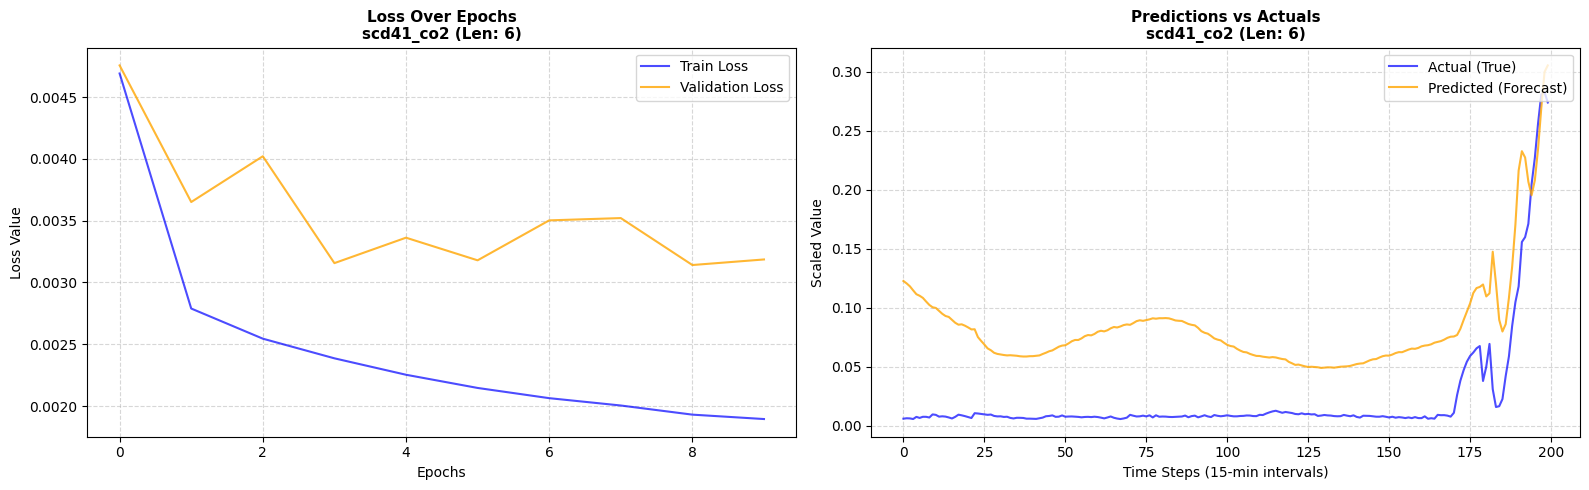

Finished displaying graphs for scd41_co2 (len=6)

TRAINING NOW: Target = scd41_co2 | Output Length = 12

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25213, 24, 18)
Sequence target shape: (25213, 12)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38913, 24, 18)
Sequence target shape: (38913, 12)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18113, 24, 18)
Sequence target shape: (18113, 12)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 12])
Epoch 1, Train Loss: 0.005113, Val Loss: 0.005362
Epoch 2, Train Loss: 0.003430, Val Loss: 0.005371
Epoch 3, Train Loss: 0.003227, Val Loss: 0.005478
Epoch 4, Train

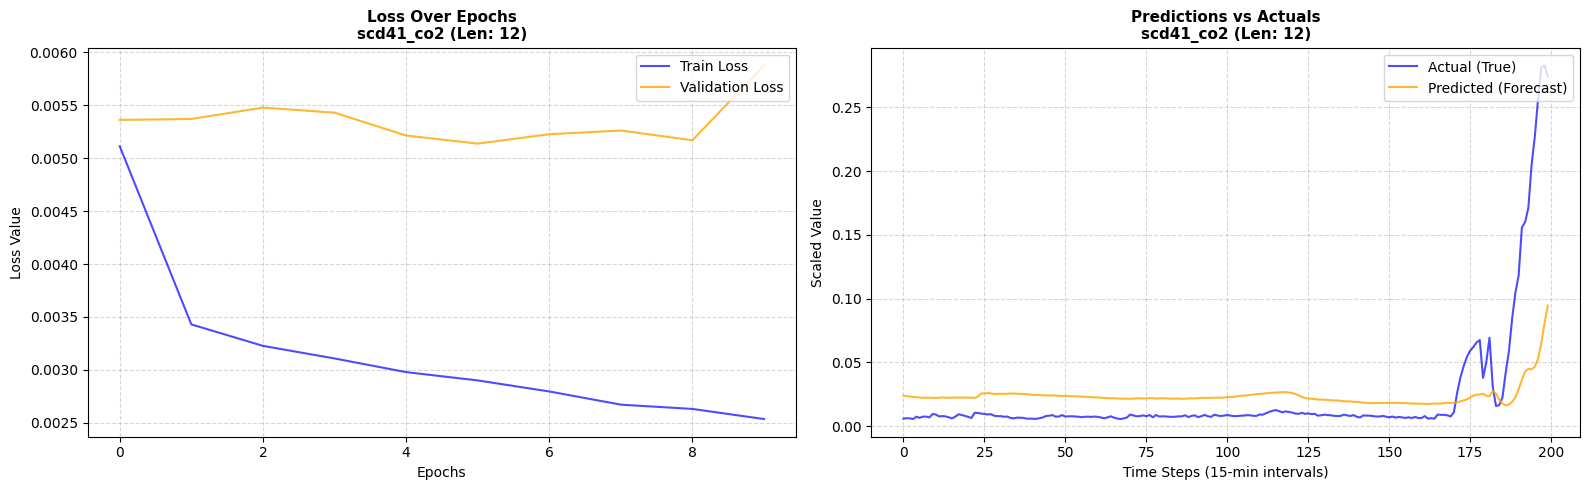

Finished displaying graphs for scd41_co2 (len=12)

ALL EXPERIMENTS FINISHED! Everything is displayed above.


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Force Jupyter to display matplotlib plots directly inside the notebook inline
%matplotlib inline

global TARGET, model_features

# ==========================================
# 1. PIPELINE FUNCTION WRAPPER
# ==========================================
def run_pipeline(target_feature, output_seq_length, epochs=10):
    global TARGET, model_features
    TARGET = target_feature 
    input_seq_length = 24  
    batch_size = 32
    
    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)
    
    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)
    
    # Dynamically switches based on whether you are running the LSTM or CNNLSTM notebook
    if 'CNNLSTMModel' in globals():
        model = CNNLSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    else:
        model = LSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
        
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)
    
    return {
        "predictions": predictions,
        "actuals": actuals,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# ==========================================
# 2. MASTER EXPERIMENT LOOP (IMMEDIATE VISUAL OUTPUT)
# ==========================================
output_lengths = [1, 6, 12]
target_features = [
    "ens160_aqi", 
    "ens160_tvoc", 
    "scd41_temperature", 
    "scd41_humidity", 
    "scd41_co2"
]

print("Starting automation run... Plots will appear one-by-one immediately after training!")

for target in target_features:
    for out_len in output_lengths:
        print("\n" + "="*60)
        print(f"TRAINING NOW: Target = {target} | Output Length = {out_len}")
        print("="*60)
        
        try:
            results = run_pipeline(
                target_feature=target, 
                output_seq_length=out_len,
                epochs=10
            )
            
            # Extract target lines for predictions
            if out_len > 1:
                plot_actuals = results["actuals"][:200, 0]
                plot_preds = results["predictions"][:200, 0]
            else:
                plot_actuals = results["actuals"][:200].flatten()
                plot_preds = results["predictions"][:200].flatten()
            
            # ------------------------------------------------------------
            # PLOT IMMEDIATELY SIDE-BY-SIDE (1 Row, 2 Columns)
            # ------------------------------------------------------------
            fig, axes = plt.subplots(1, 2, figsize=(16, 5))
            
            # Left Plot: Loss Curve
            axes[0].plot(results["train_losses"], label="Train Loss", color="blue", alpha=0.7)
            axes[0].plot(results["val_losses"], label="Validation Loss", color="orange", alpha=0.8)
            axes[0].set_title(f"Loss Over Epochs\n{target} (Len: {out_len})", fontsize=11, fontweight="bold")
            axes[0].set_xlabel("Epochs")
            axes[0].set_ylabel("Loss Value")
            axes[0].legend(loc="upper right")
            axes[0].grid(True, linestyle="--", alpha=0.5)
            
            # Right Plot: Predictions vs Actuals
            axes[1].plot(plot_actuals, label="Actual (True)", color="blue", alpha=0.7)
            axes[1].plot(plot_preds, label="Predicted (Forecast)", color="orange", alpha=0.8)
            axes[1].set_title(f"Predictions vs Actuals\n{target} (Len: {out_len})", fontsize=11, fontweight="bold")
            axes[1].set_xlabel("Time Steps (15-min intervals)")
            axes[1].set_ylabel("Scaled Value")
            axes[1].legend(loc="upper right")
            axes[1].grid(True, linestyle="--", alpha=0.5)
            
            plt.tight_layout()
            plt.show()  # <--- THIS forces Jupyter to display the pair instantly on screen!
            
            print(f"Finished displaying graphs for {target} (len={out_len})")
            
        except Exception as e:
            print(f"Error during variant [{target} | Length {out_len}]: {e}")

print("\nALL EXPERIMENTS FINISHED! Everything is displayed above.")

Starting automation run... Plots will appear one-by-one immediately after training!

TRAINING NOW: Target = ens160_aqi | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])
Epoch 1, Train Loss: 0.003022, Val Loss: 0.002831
Epoch 2, Train Loss: 0.001449, Val Loss: 0.002435
Epoch 3, Train Loss: 0.00133

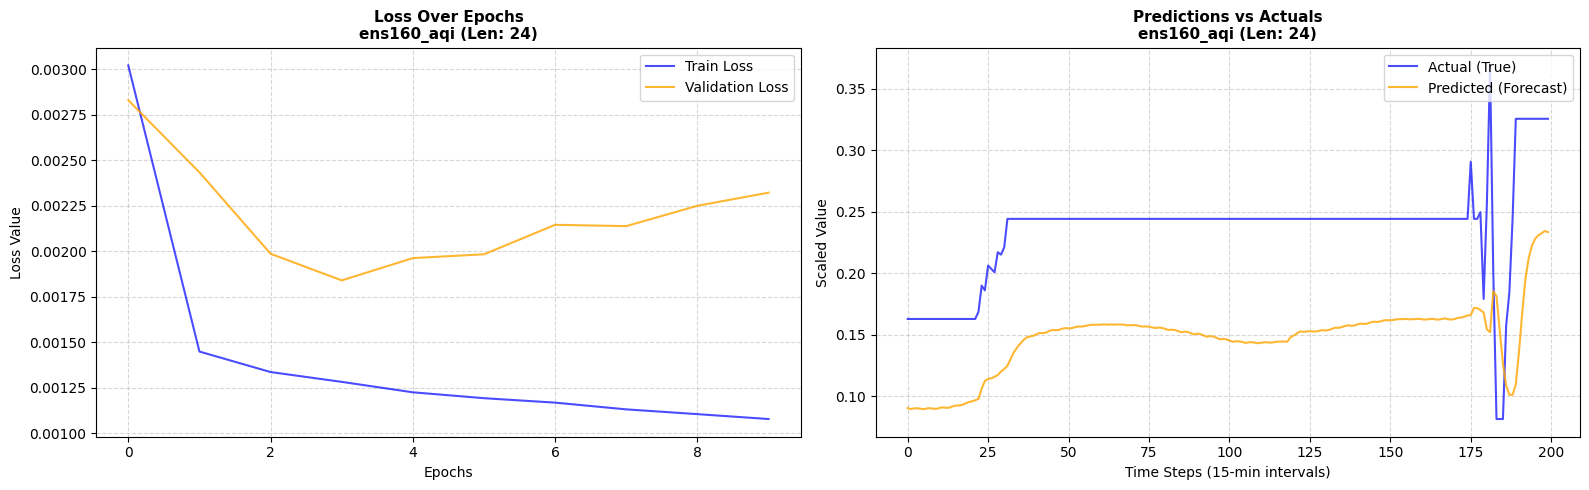

Finished displaying graphs for ens160_aqi (len=24)

TRAINING NOW: Target = ens160_aqi | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])
Epoch 1, Train Loss: 0.003933, Val Loss: 0.005938
Epoch 2, Train Loss: 0.001849, Val Loss: 0.006092
Epoch 3, Train Loss: 0.001716, Val Loss: 0.004991
Epoch 4, Tr

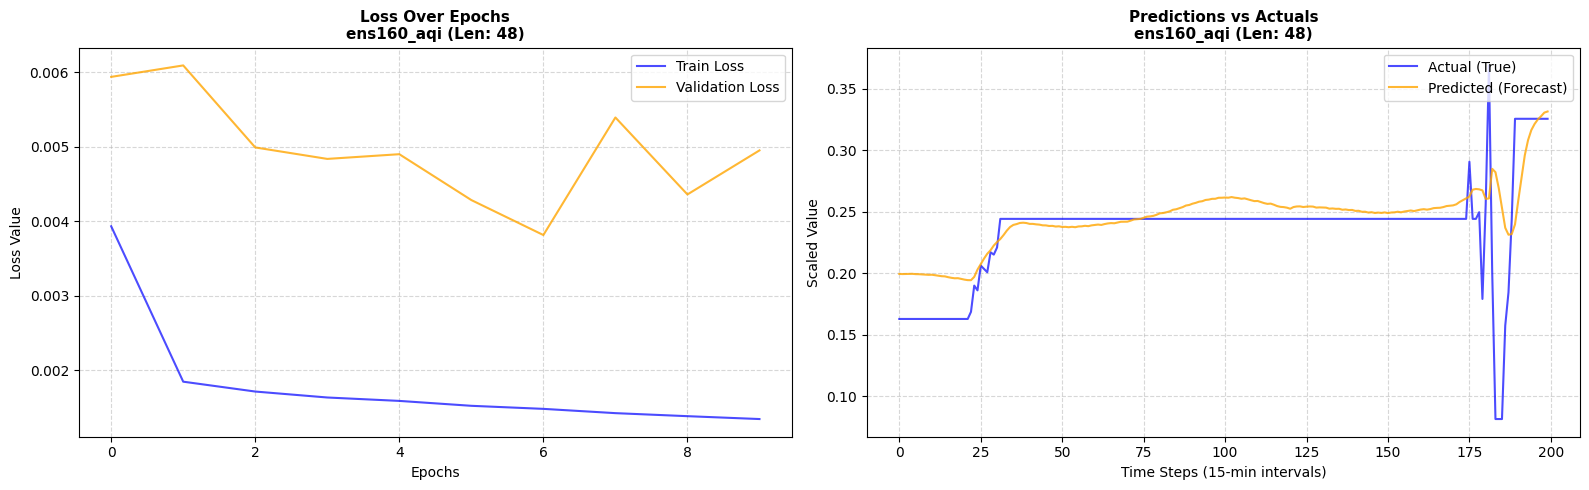

Finished displaying graphs for ens160_aqi (len=48)

TRAINING NOW: Target = ens160_tvoc | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])
Epoch 1, Train Loss: 0.001477, Val Loss: 0.001039
Epoch 2, Train Loss: 0.000799, Val Loss: 0.000928
Epoch 3, Train Loss: 0.000766, Val Loss: 0.000938
Epoch 4, T

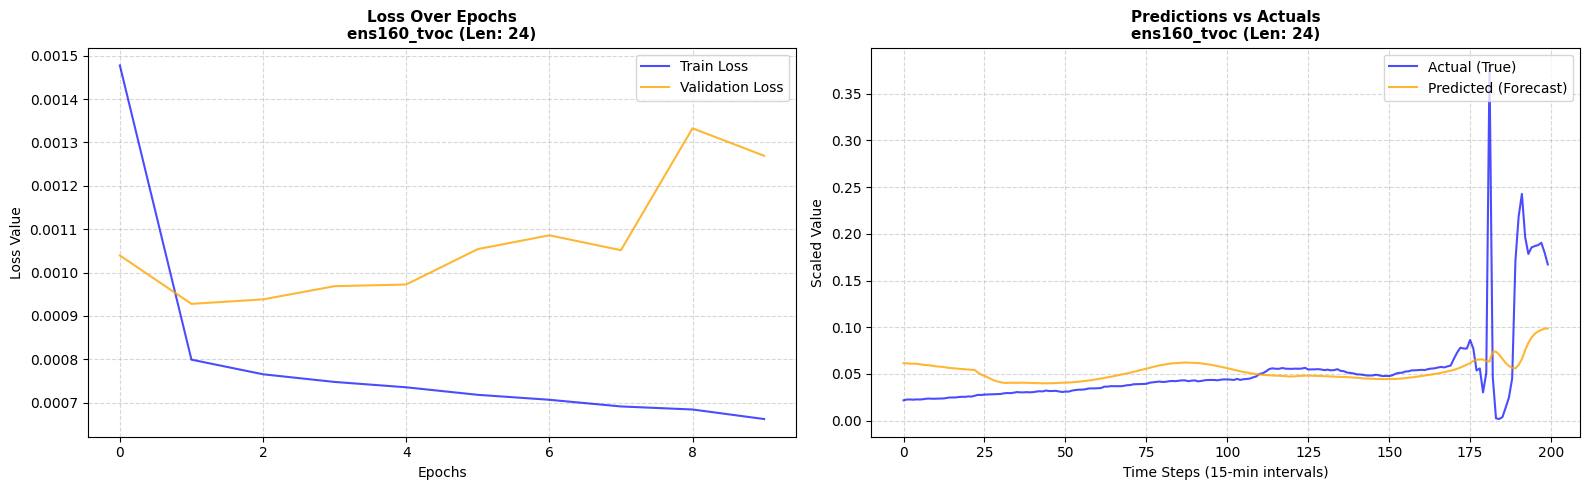

Finished displaying graphs for ens160_tvoc (len=24)

TRAINING NOW: Target = ens160_tvoc | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])
Epoch 1, Train Loss: 0.001639, Val Loss: 0.000861
Epoch 2, Train Loss: 0.000977, Val Loss: 0.000725
Epoch 3, Train Loss: 0.000928, Val Loss: 0.000756
Epoch 4, 

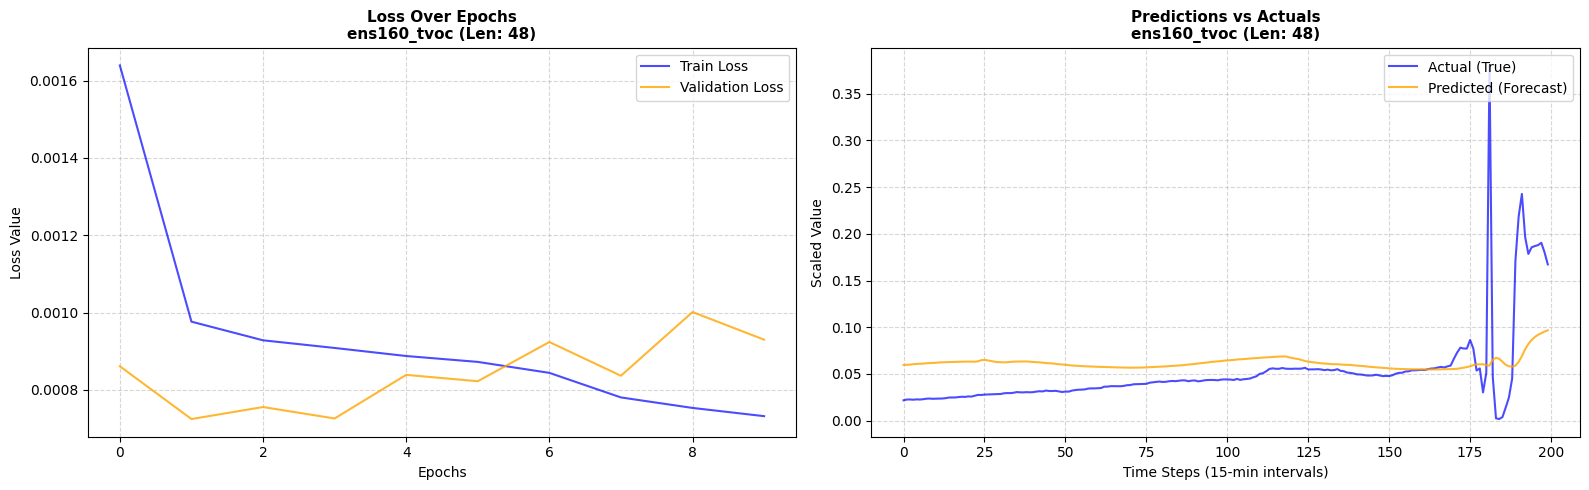

Finished displaying graphs for ens160_tvoc (len=48)

TRAINING NOW: Target = scd41_temperature | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])
Epoch 1, Train Loss: 0.034458, Val Loss: 0.022750
Epoch 2, Train Loss: 0.004311, Val Loss: 0.016596
Epoch 3, Train Loss: 0.003295, Val Loss: 0.014488
Epo

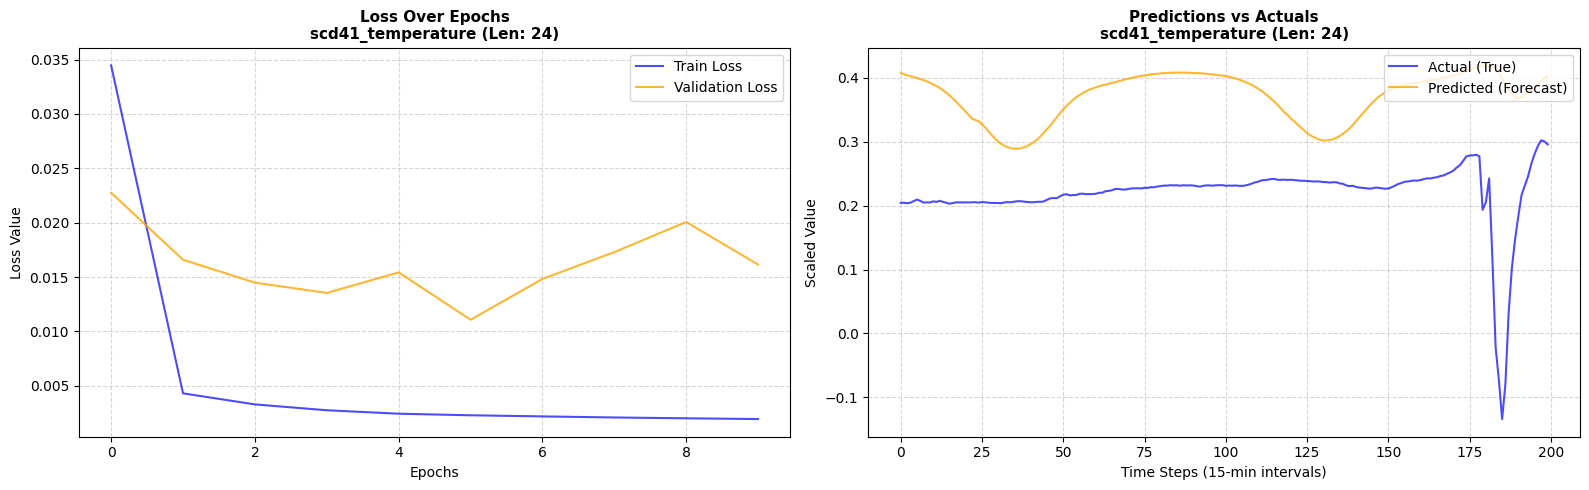

Finished displaying graphs for scd41_temperature (len=24)

TRAINING NOW: Target = scd41_temperature | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])
Epoch 1, Train Loss: 0.037225, Val Loss: 0.014141
Epoch 2, Train Loss: 0.005311, Val Loss: 0.012749
Epoch 3, Train Loss: 0.004119, Val Loss: 0.0172

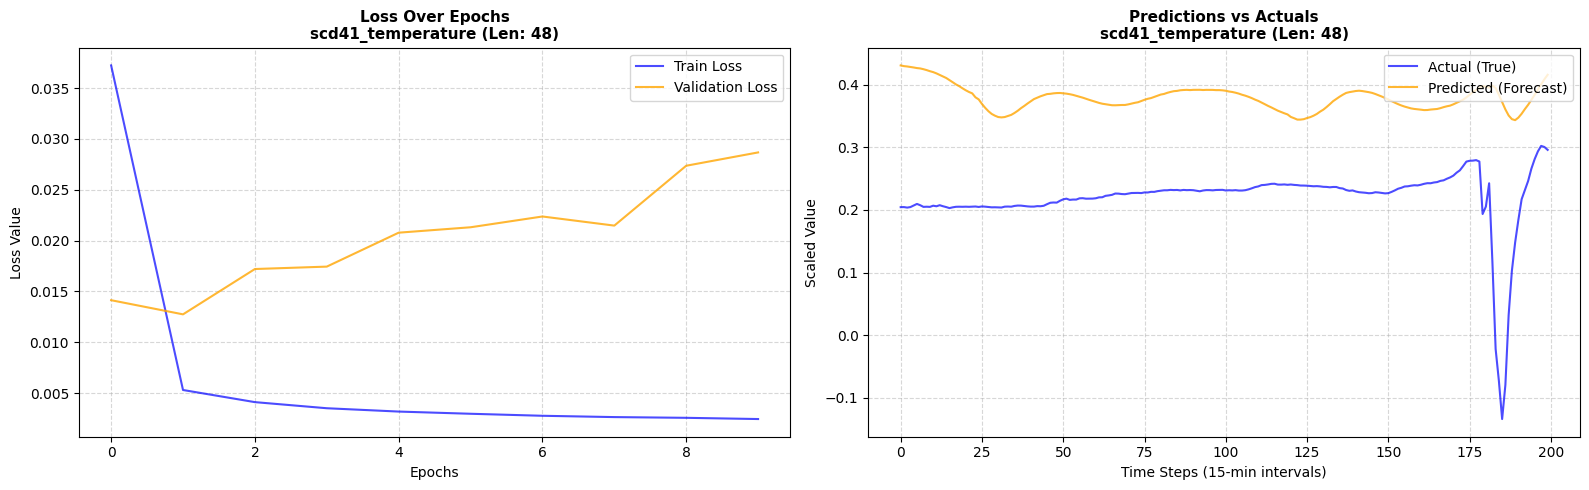

Finished displaying graphs for scd41_temperature (len=48)

TRAINING NOW: Target = scd41_humidity | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])
Epoch 1, Train Loss: 0.018146, Val Loss: 0.006767
Epoch 2, Train Loss: 0.002575, Val Loss: 0.010087
Epoch 3, Train Loss: 0.002293, Val Loss: 0.010497


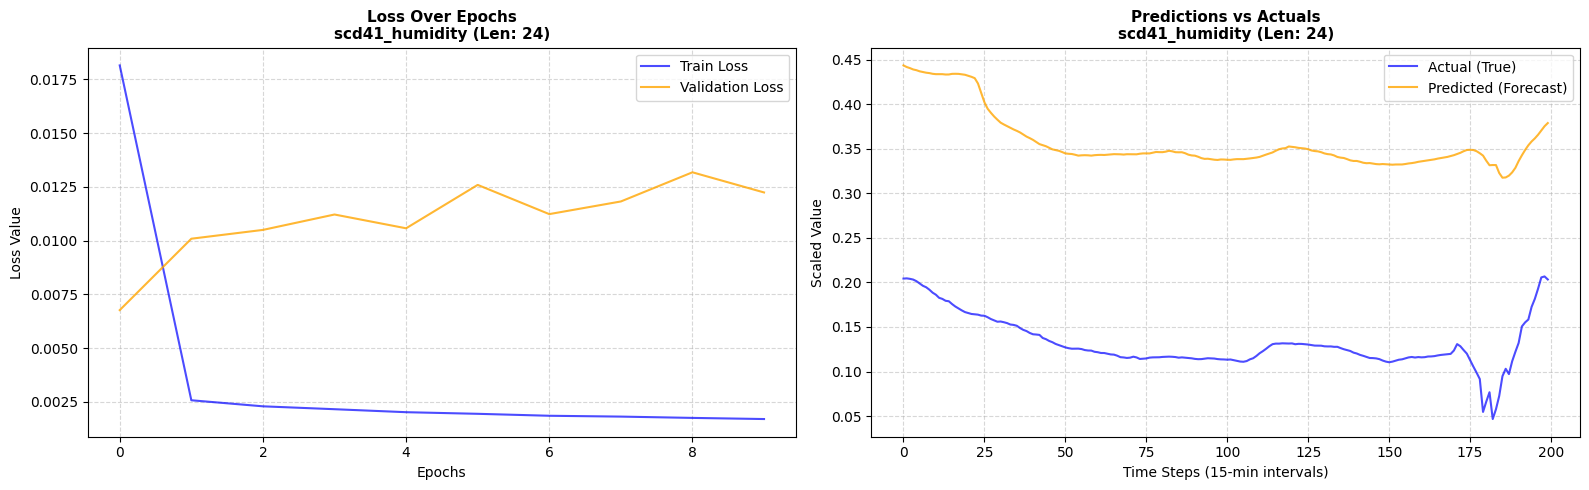

Finished displaying graphs for scd41_humidity (len=24)

TRAINING NOW: Target = scd41_humidity | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])
Epoch 1, Train Loss: 0.018379, Val Loss: 0.016937
Epoch 2, Train Loss: 0.003488, Val Loss: 0.013246
Epoch 3, Train Loss: 0.003207, Val Loss: 0.014595
Epo

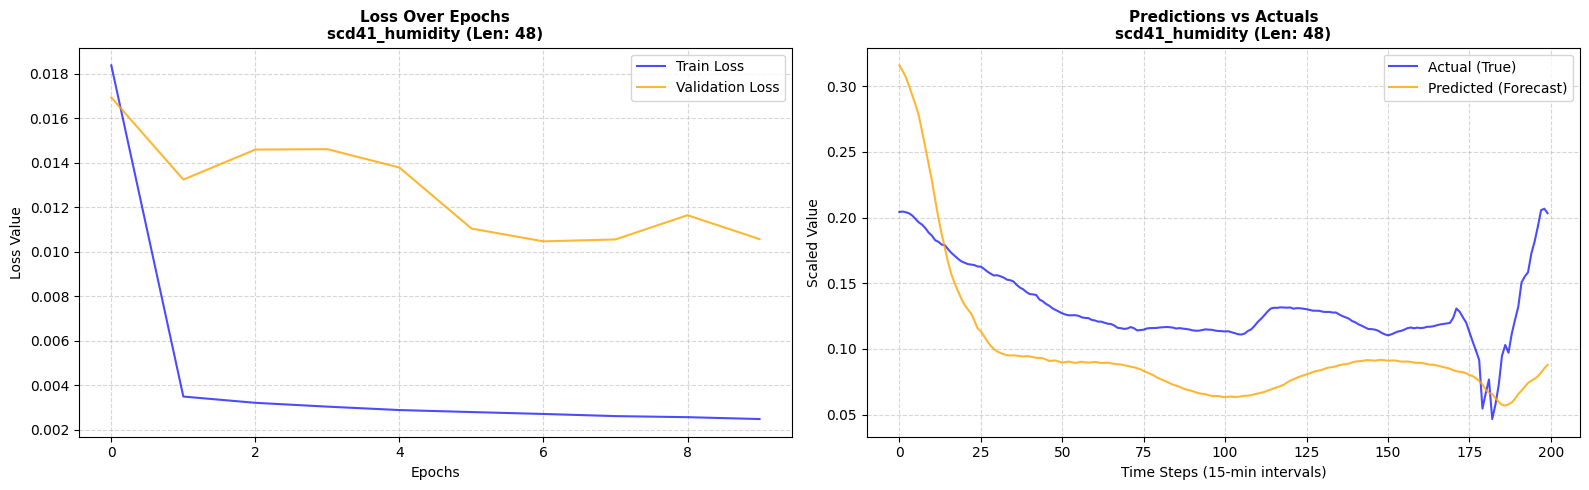

Finished displaying graphs for scd41_humidity (len=48)

TRAINING NOW: Target = scd41_co2 | Output Length = 24

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25201, 24, 18)
Sequence target shape: (25201, 24)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38901, 24, 18)
Sequence target shape: (38901, 24)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18101, 24, 18)
Sequence target shape: (18101, 24)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 24])
Epoch 1, Train Loss: 0.005891, Val Loss: 0.006323
Epoch 2, Train Loss: 0.004090, Val Loss: 0.006757
Epoch 3, Train Loss: 0.003809, Val Loss: 0.006512
Epoch 4,

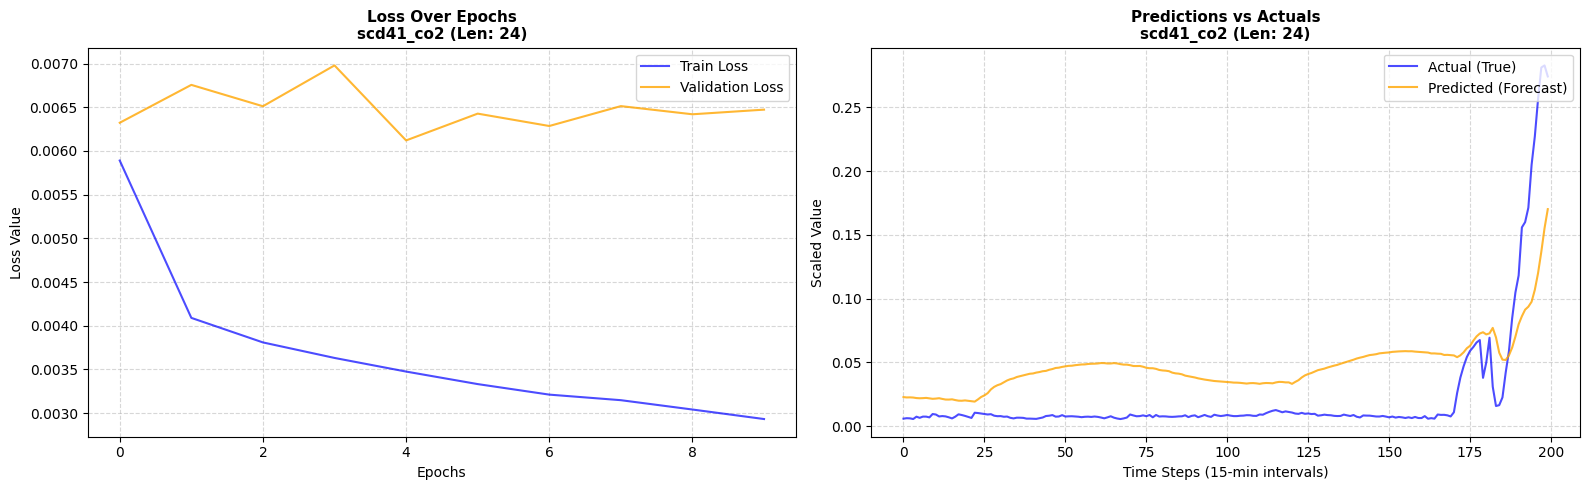

Finished displaying graphs for scd41_co2 (len=24)

TRAINING NOW: Target = scd41_co2 | Output Length = 48

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25177, 24, 18)
Sequence target shape: (25177, 48)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38877, 24, 18)
Sequence target shape: (38877, 48)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18077, 24, 18)
Sequence target shape: (18077, 48)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 48])
Epoch 1, Train Loss: 0.006488, Val Loss: 0.008426
Epoch 2, Train Loss: 0.004830, Val Loss: 0.010943
Epoch 3, Train Loss: 0.004551, Val Loss: 0.009233
Epoch 4, Trai

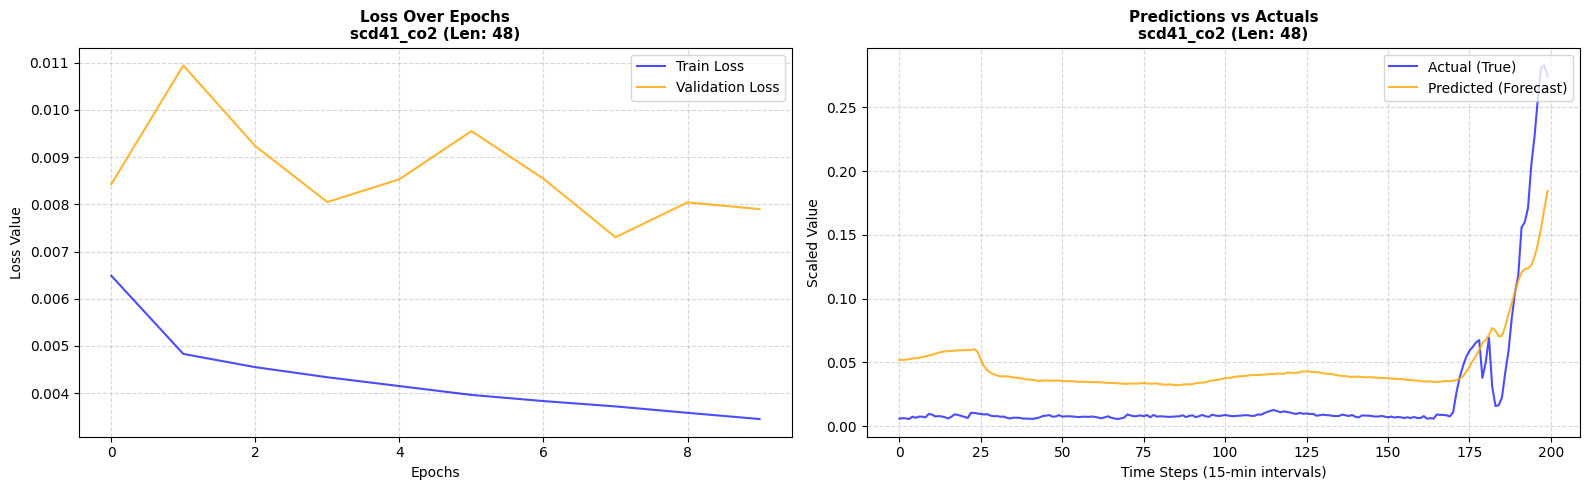

Finished displaying graphs for scd41_co2 (len=48)

ALL EXPERIMENTS FINISHED! Everything is displayed above.


## 28. This Code Below Is Show The All Results Here



Starting automation run... Processing variants...
Processing: Target = ens160_aqi | Length = 1

Original data shape before sequencing: (25249, 18)
Sequence input shape: (25224, 24, 18)
Sequence target shape: (25224, 1)

Original data shape before sequencing: (38949, 18)
Sequence input shape: (38924, 24, 18)
Sequence target shape: (38924, 1)

Original data shape before sequencing: (18149, 18)
Sequence input shape: (18124, 24, 18)
Sequence target shape: (18124, 1)

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])

========== DATALOADER ==========
Batch input shape: torch.Size([32, 24, 18])
Batch target shape: torch.Size([32, 1])
Epoch 1, Train Loss: 0.001270, Val Loss: 0.005789
Epoch 2, Train Loss: 0.000645, Val Loss: 0.007228
Epoch 3, Train Loss: 0.000520, Val Loss: 0.006793
Epoch 4, Train Loss: 0.000460

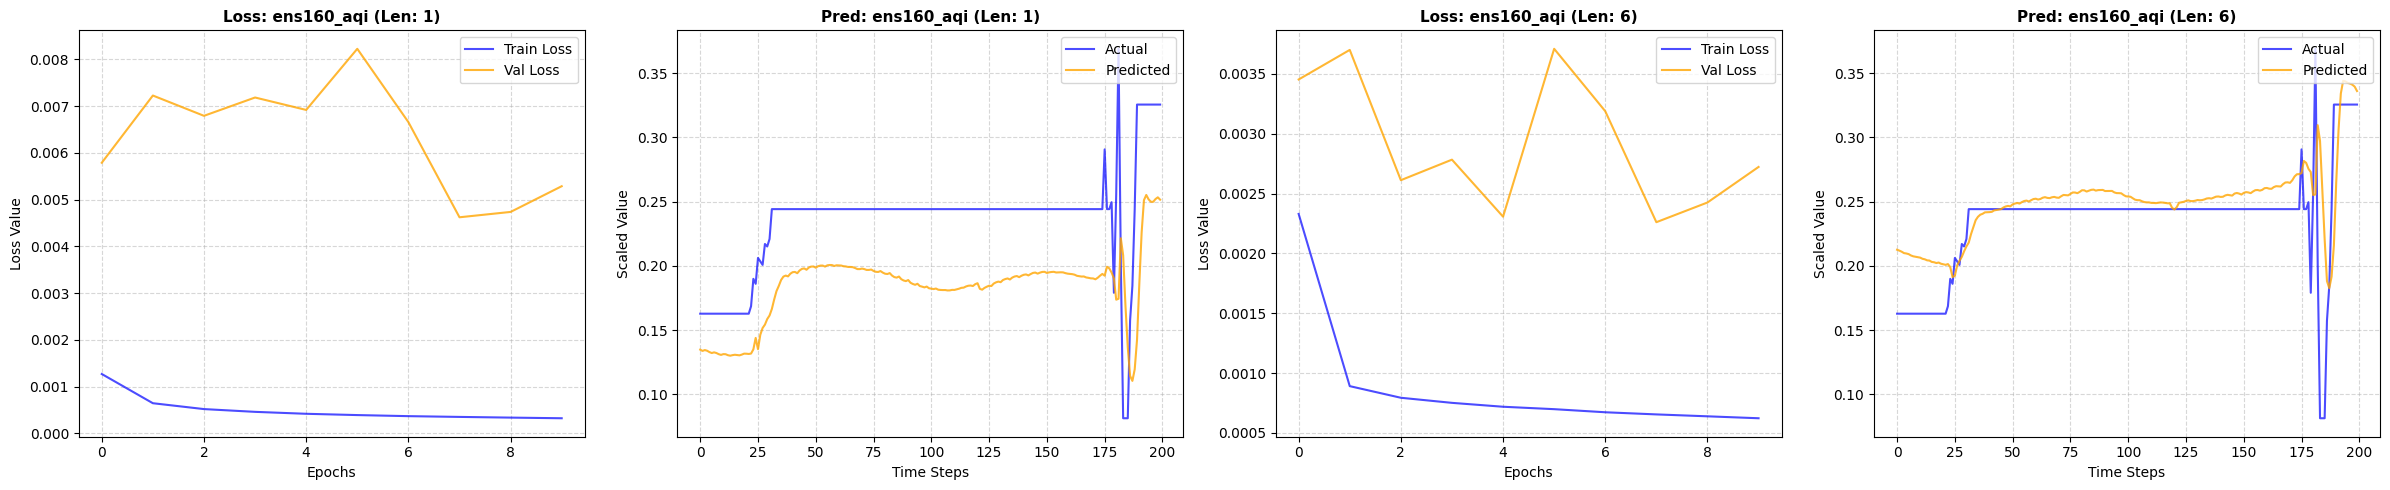

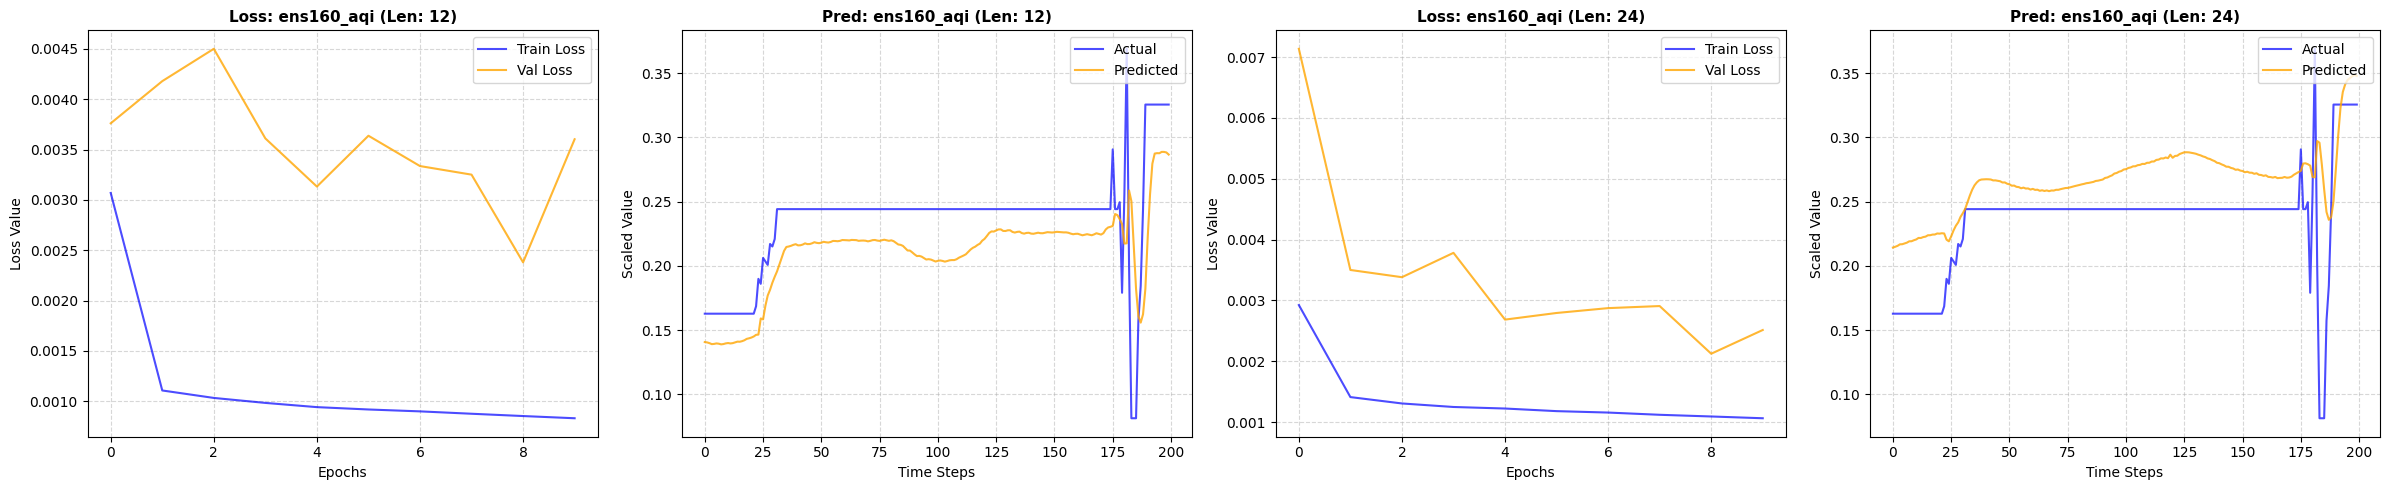

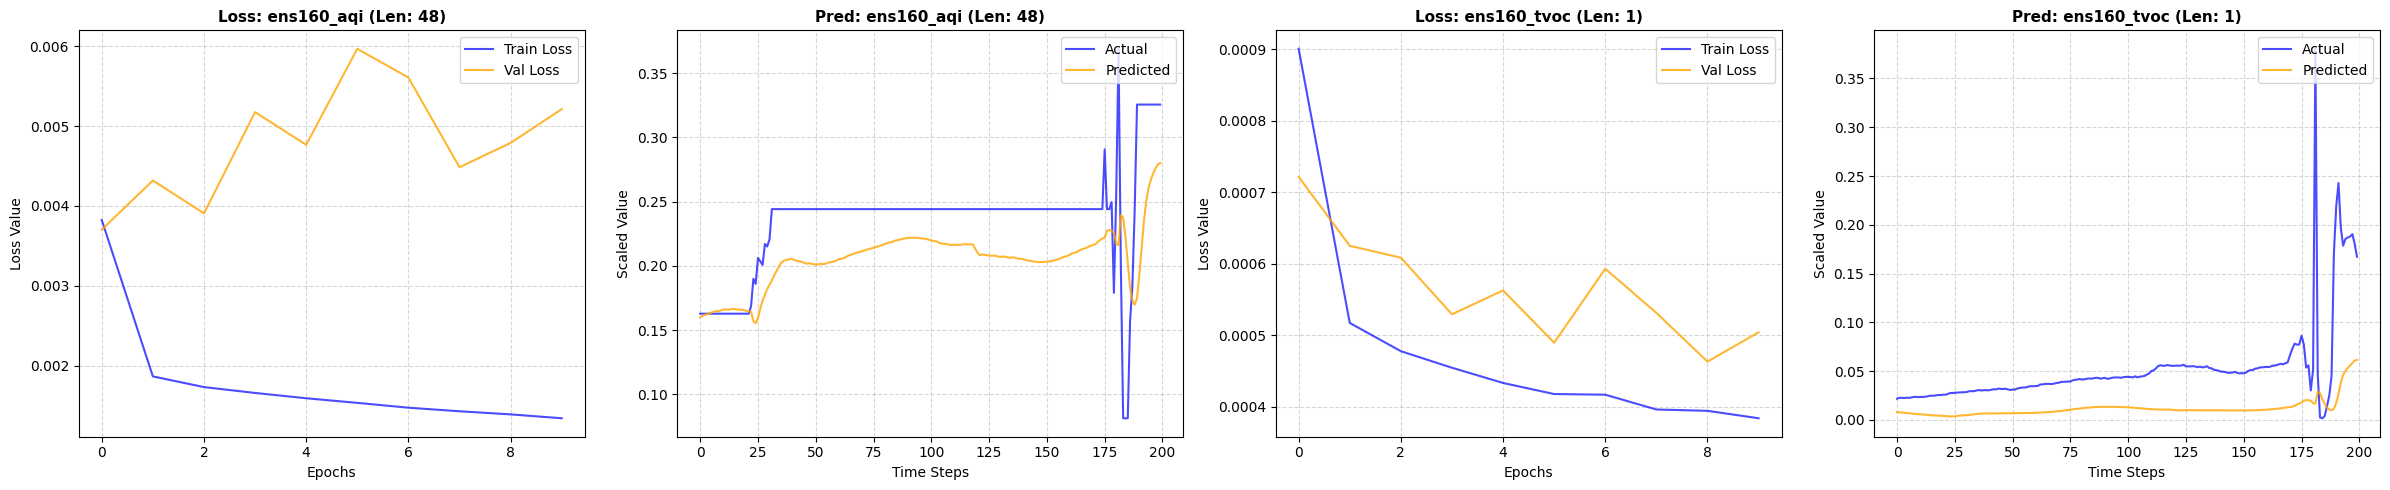

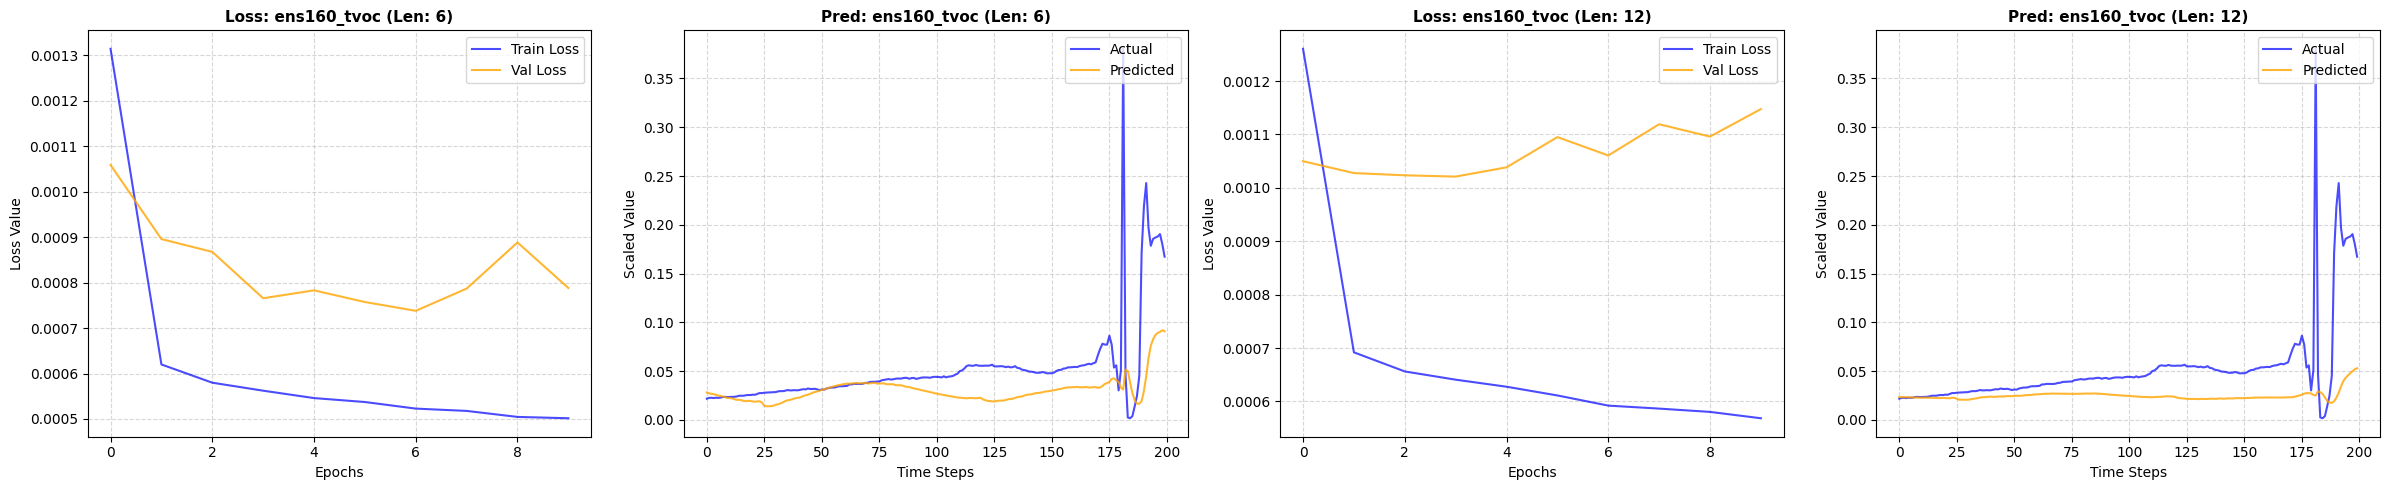

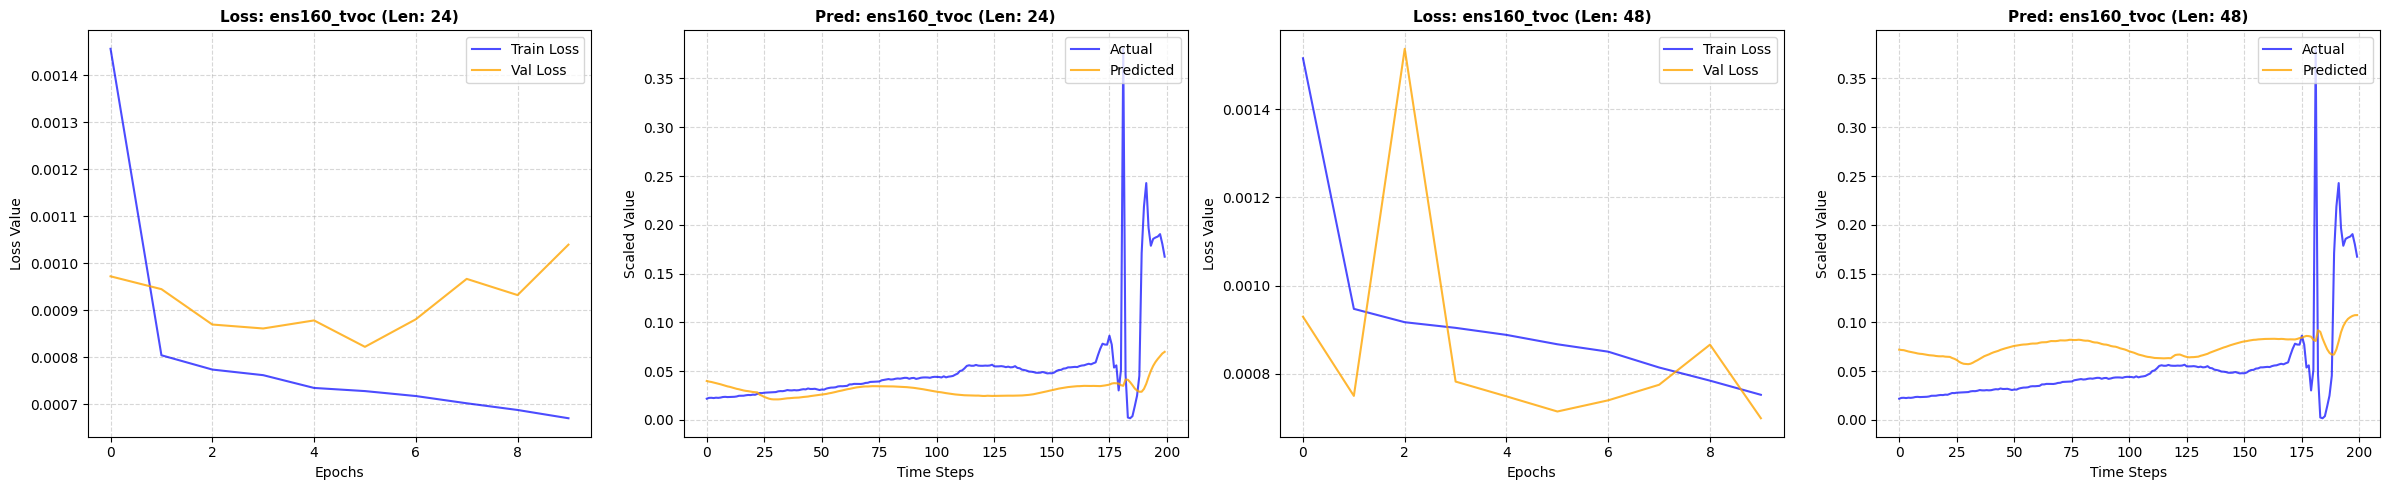

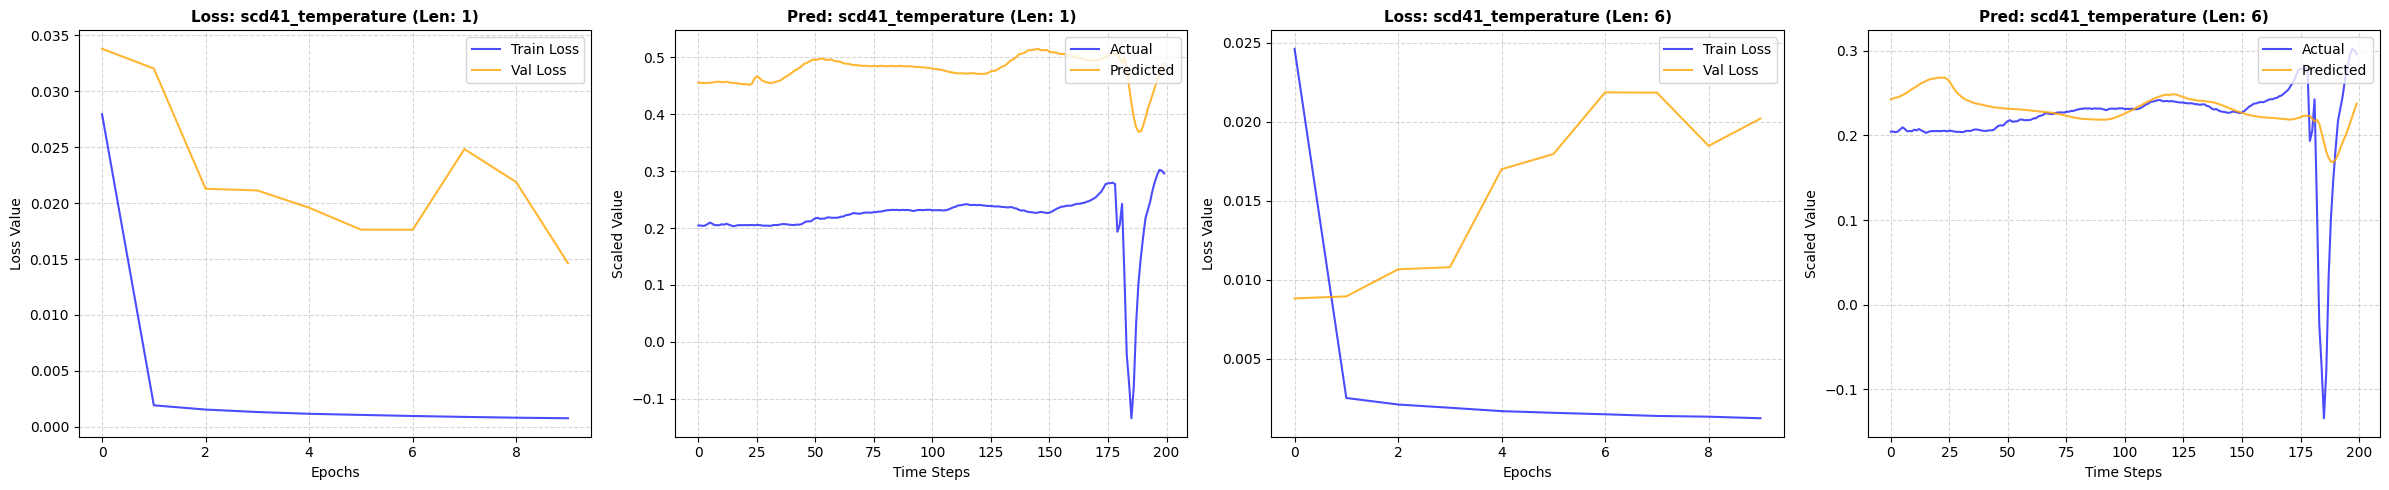

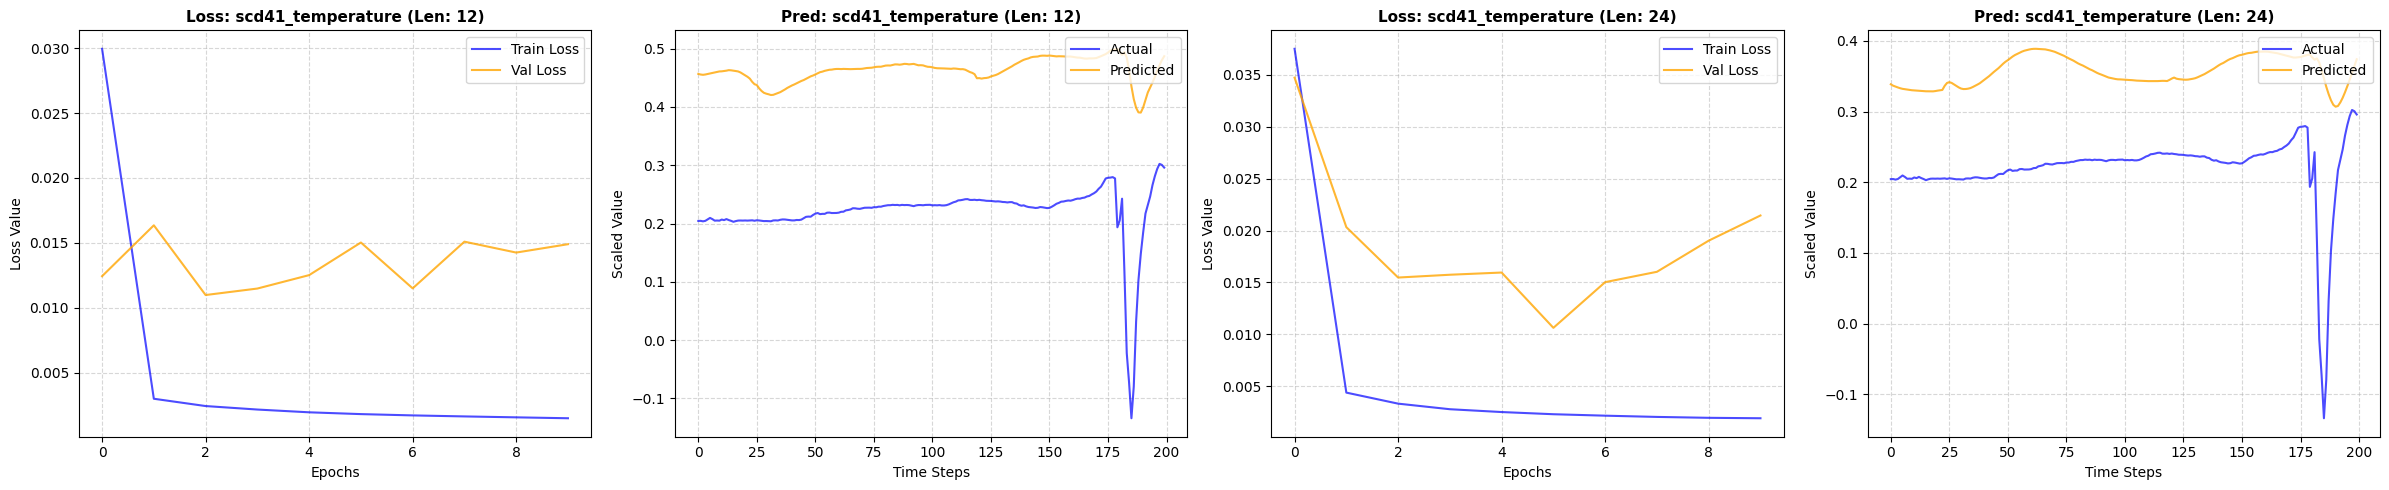

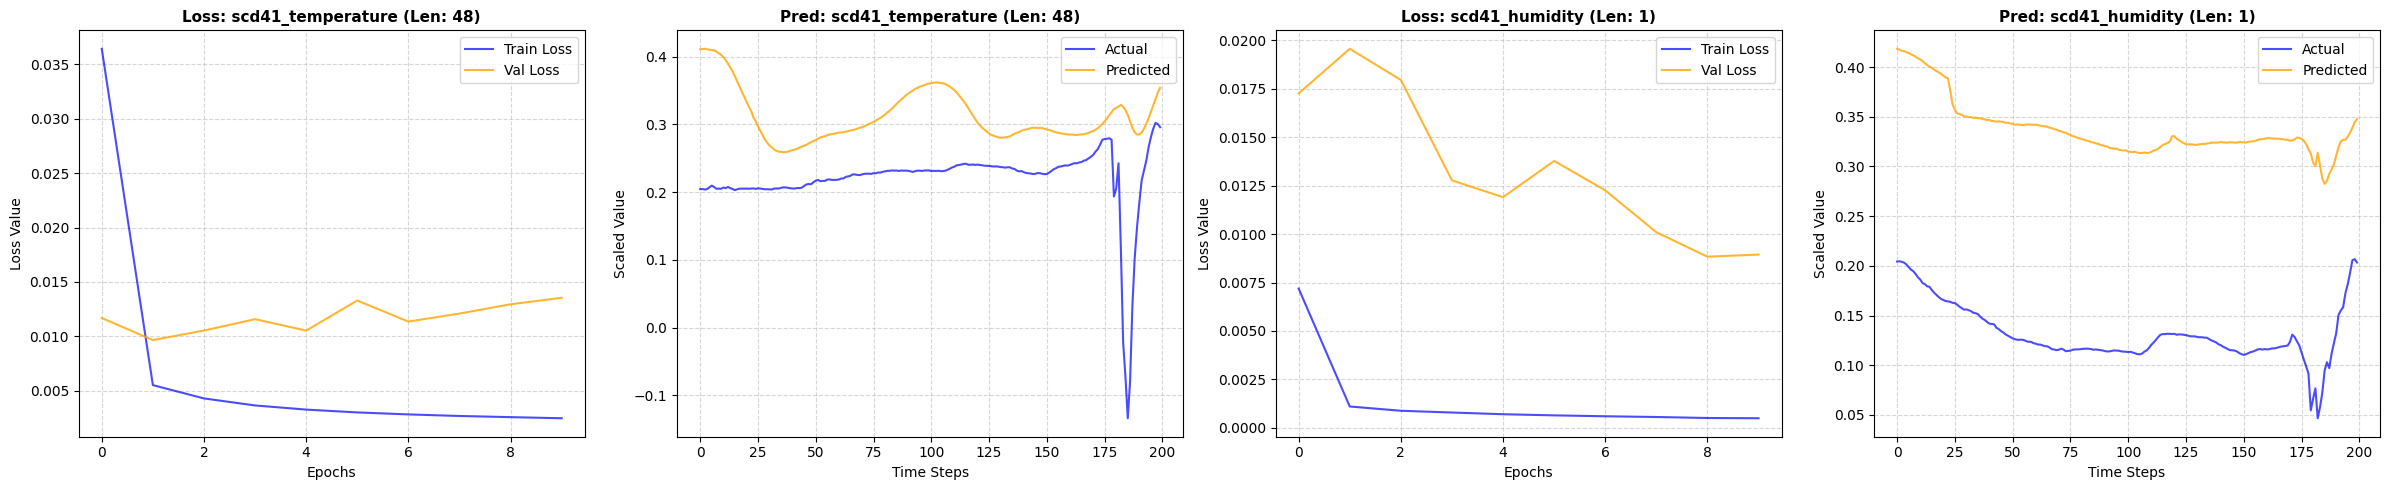

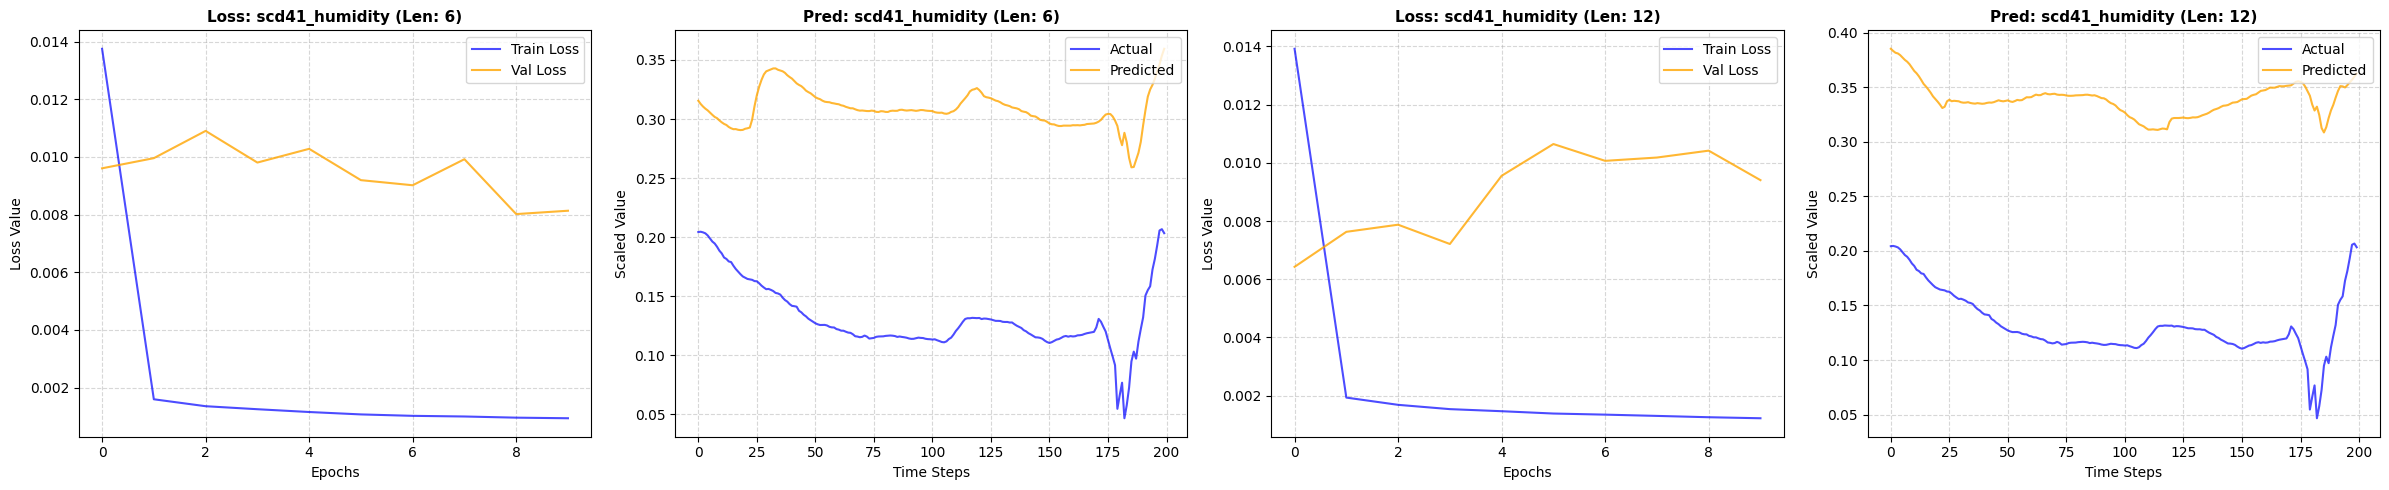

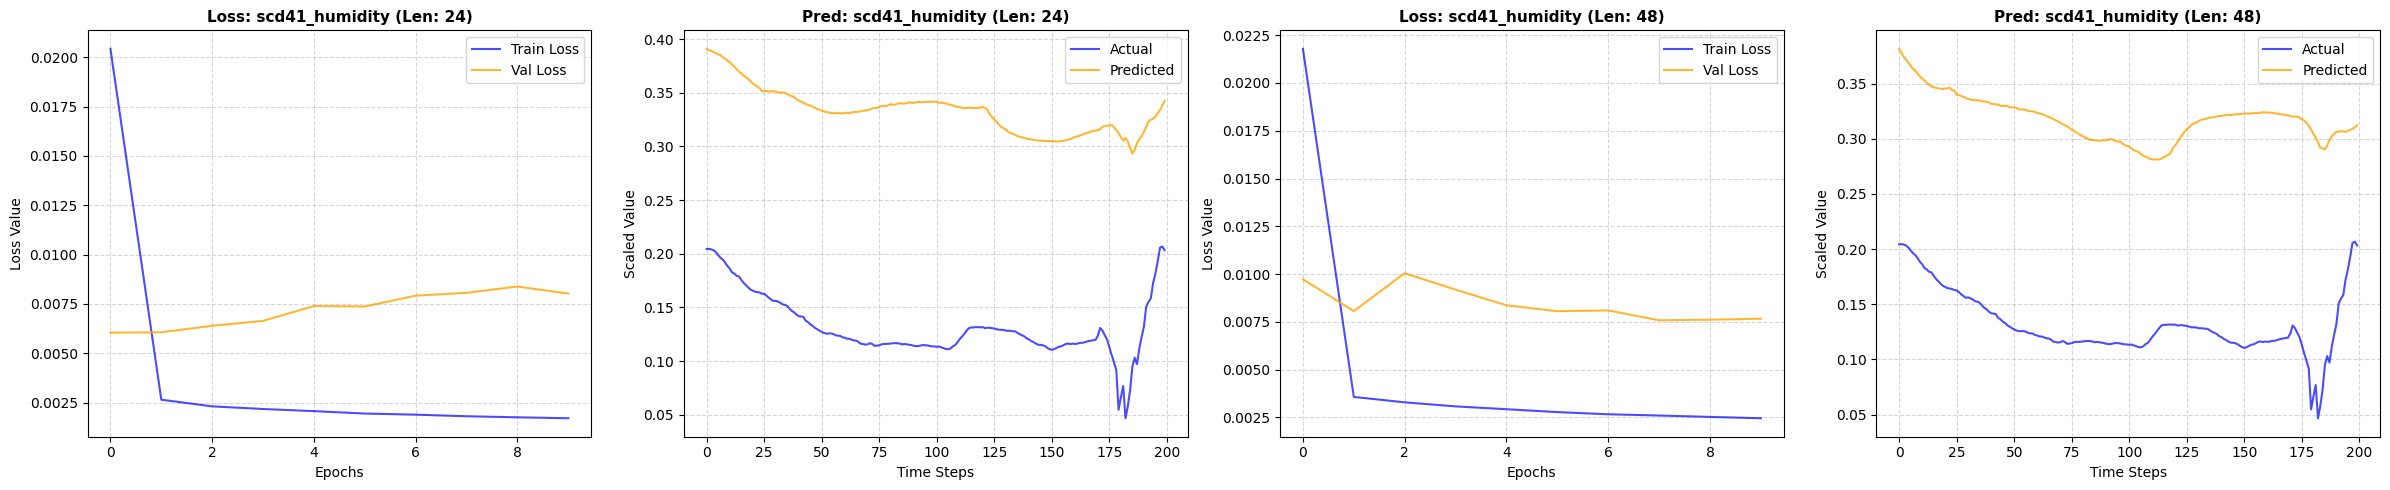

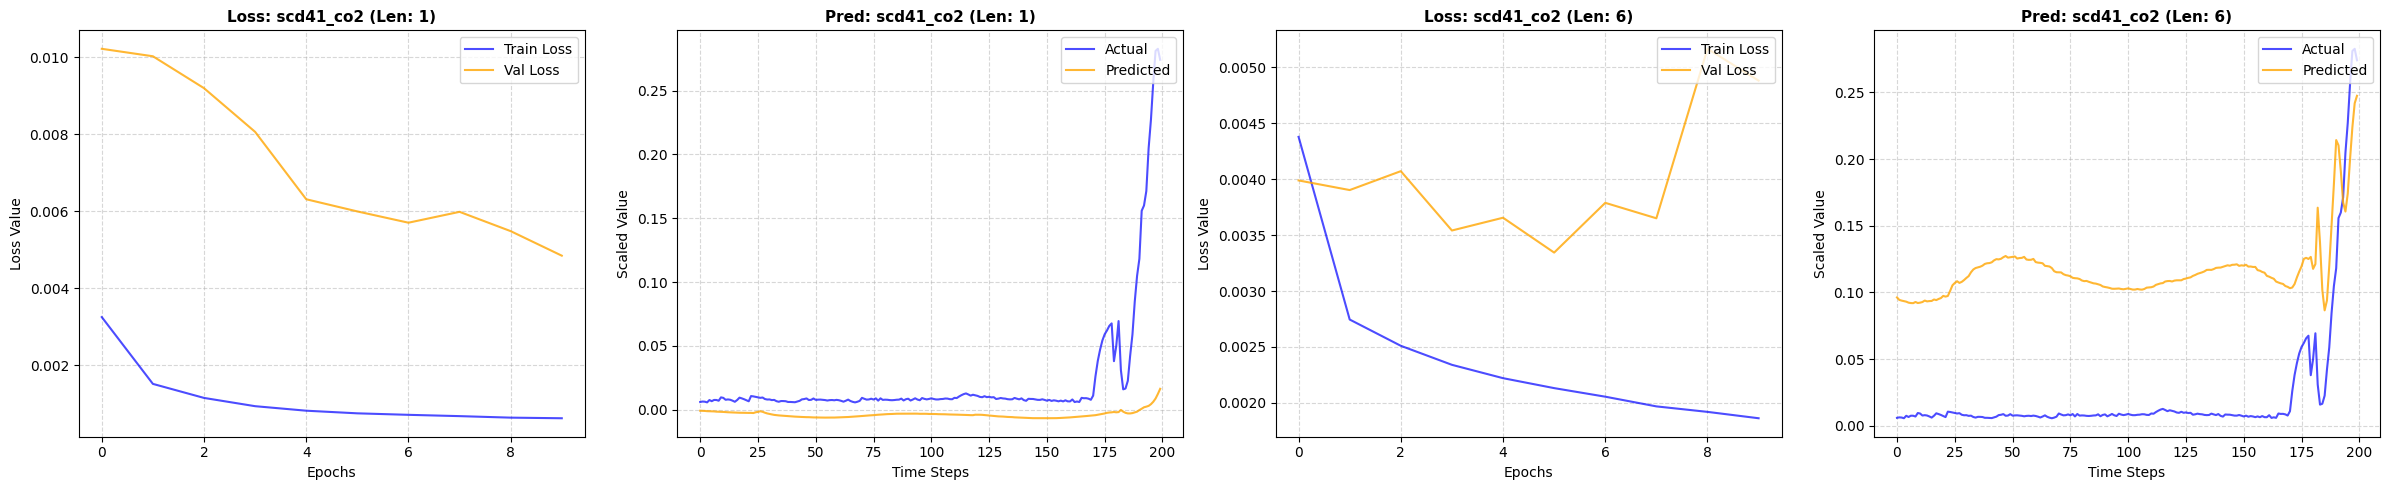

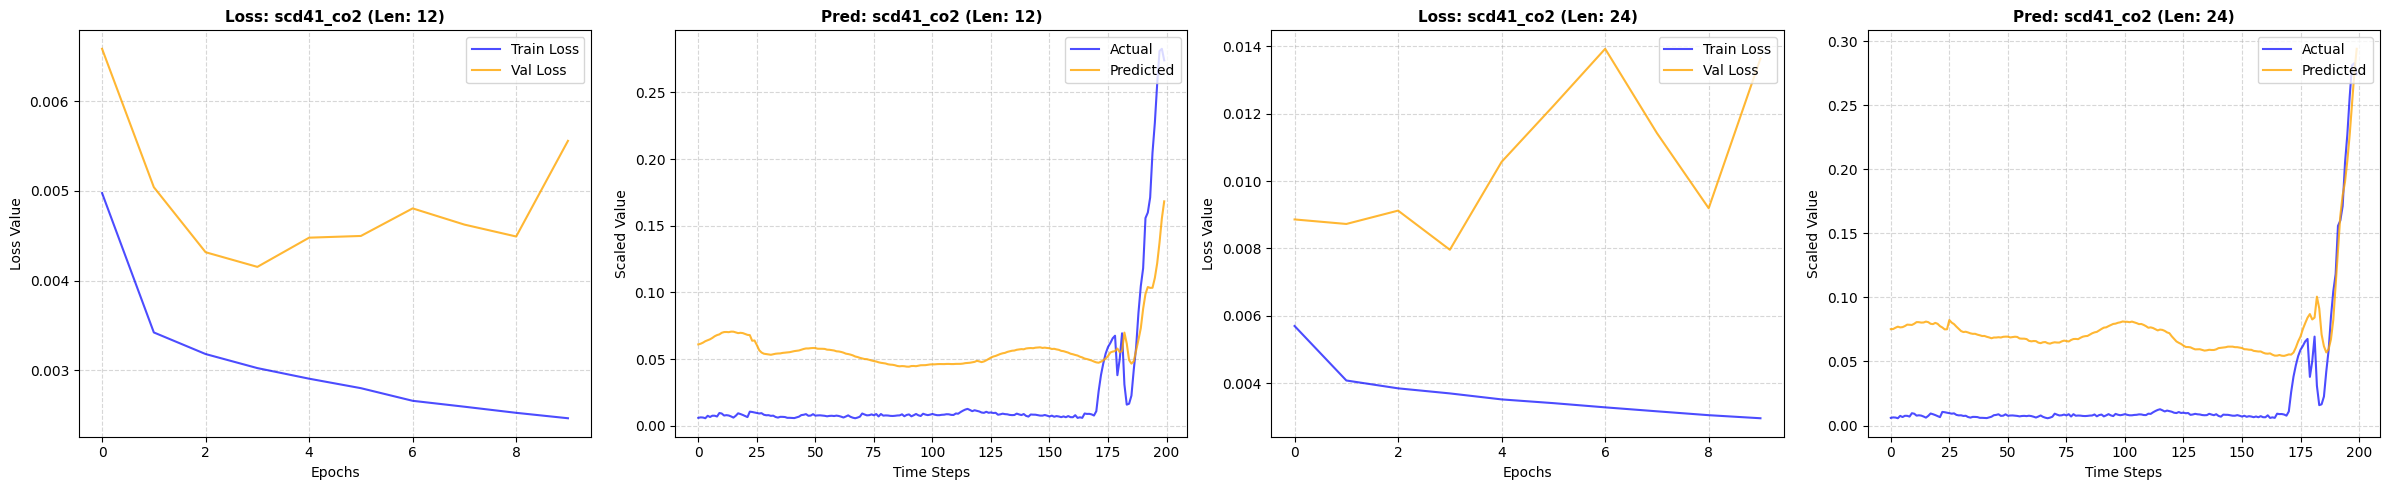

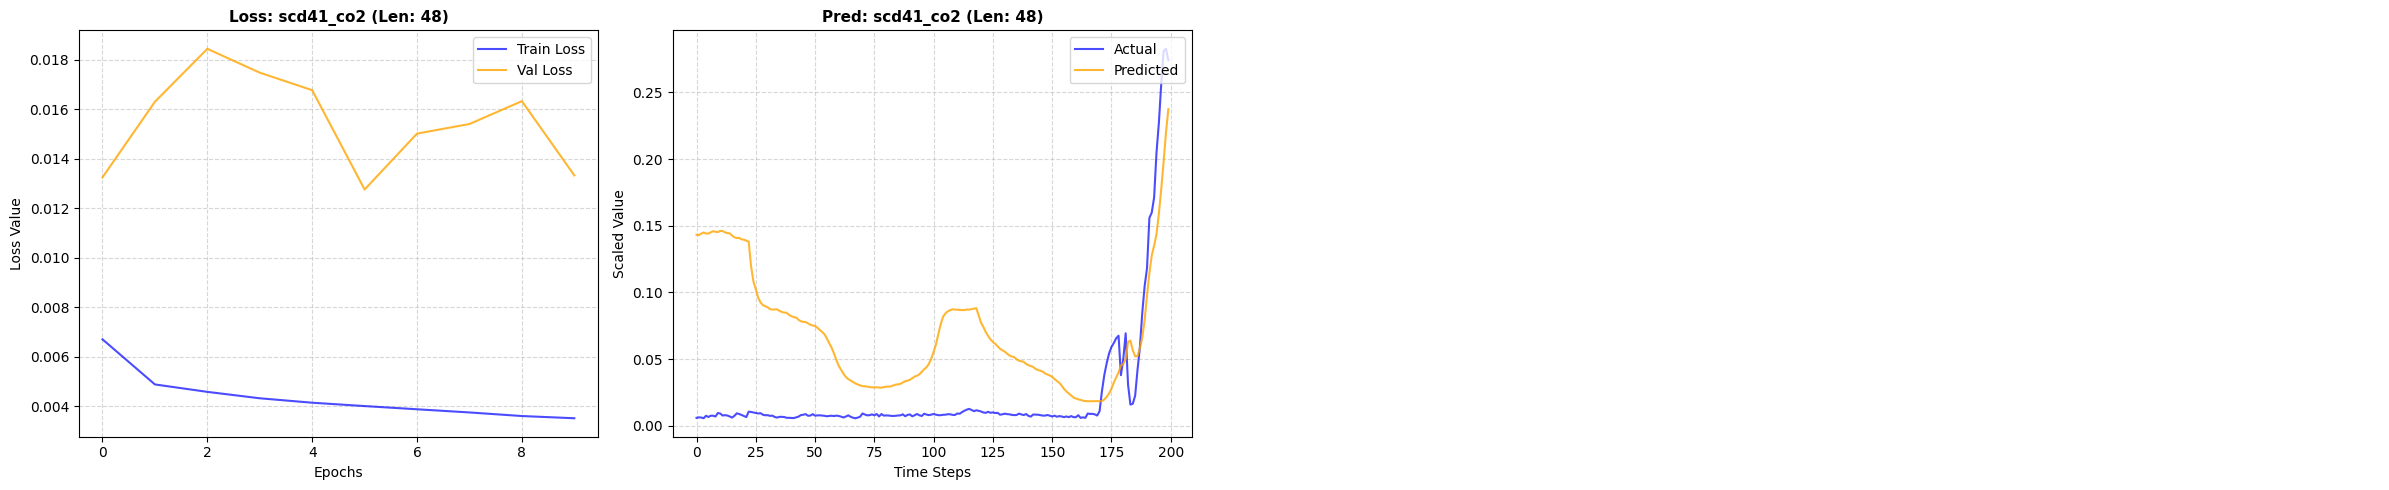


 ALL EXPERIMENTS FINISHED! Everything displayed above.


In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Force Jupyter to display matplotlib plots directly inside the notebook inline
%matplotlib inline

global TARGET, model_features

# ==========================================
# 1. PIPELINE FUNCTION WRAPPER
# ==========================================
def run_pipeline(target_feature, output_seq_length, epochs=10):
    global TARGET, model_features
    TARGET = target_feature 
    input_seq_length = 24  
    batch_size = 32
    
    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)
    
    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)
    
    # Dynamically switches based on whether you are running the LSTM or CNNLSTM notebook
    if 'CNNLSTMModel' in globals():
        model = CNNLSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    else:
        model = LSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
        
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)
    
    return {
        "predictions": predictions,
        "actuals": actuals,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# ==========================================
# 2. MASTER EXPERIMENT LOOP WITH SUBPLOT GRID
# ==========================================
output_lengths = [1, 6, 12, 24, 48]
target_features = [
    "ens160_aqi", 
    "ens160_tvoc", 
    "scd41_temperature", 
    "scd41_humidity", 
    "scd41_co2"
]

# Define a list to collect plotting data so we can display 4 charts per row smoothly
plot_queue = []

print("Starting automation run... Processing variants...")

for target in target_features:
    for out_len in output_lengths:
        print(f"Processing: Target = {target} | Length = {out_len}")
        try:
            results = run_pipeline(
                target_feature=target, 
                output_seq_length=out_len,
                epochs=10
            )
            
            # Extract target lines for predictions
            if out_len > 1:
                plot_actuals = results["actuals"][:200, 0]
                plot_preds = results["predictions"][:200, 0]
            else:
                plot_actuals = results["actuals"][:200].flatten()
                plot_preds = results["predictions"][:200].flatten()
            
            # Queue data for the display grid
            plot_queue.append({
                "type": "loss",
                "title": f"Loss: {target} (Len: {out_len})",
                "data1": results["train_losses"],
                "data2": results["val_losses"],
                "label1": "Train Loss",
                "label2": "Val Loss"
            })
            
            plot_queue.append({
                "type": "pred",
                "title": f"Pred: {target} (Len: {out_len})",
                "data1": plot_actuals,
                "data2": plot_preds,
                "label1": "Actual",
                "label2": "Predicted"
            })
            
        except Exception as e:
            print(f" Error during variant [{target} | Length {out_len}]: {e}")

# ==========================================
# 3. RENDER THE RESULTS DIRECTLY IN JUPYTER (4 PER ROW)
# ==========================================
print("\n" + "="*60)
print("Rendering Visual Grid Directly Inside Jupyter Notebook Below:")
print("="*60 + "\n")

plots_per_row = 4
total_plots = len(plot_queue)

# Loop over the items jumping 4 at a time to build clean horizontal rows
for i in range(0, total_plots, plots_per_row):
    current_chunk = plot_queue[i : i + plots_per_row]
    num_cols = len(current_chunk)
    
    # Create an explicit wide row layout (width: 24 inches, height: 5 inches)
    fig, axes = plt.subplots(1, plots_per_row, figsize=(24, 5))
    
    # Handle indexing fallback if only 1 plot is left near the very end
    if plots_per_row == 1:
        axes = [axes]
        
    for col_idx in range(plots_per_row):
        ax = axes[col_idx]
        
        if col_idx < num_cols:
            item = current_chunk[col_idx]
            
            # Plot the specific lines assigned to this column quadrant
            ax.plot(item["data1"], label=item["label1"], color="blue", alpha=0.7)
            ax.plot(item["data2"], label=item["label2"], color="orange", alpha=0.8)
            ax.set_title(item["title"], fontsize=11, fontweight="bold")
            ax.legend(loc="upper right")
            ax.grid(True, linestyle="--", alpha=0.5)
            
            # Add structural labels depending on graph context
            if item["type"] == "loss":
                ax.set_xlabel("Epochs")
                ax.set_ylabel("Loss Value")
            else:
                ax.set_xlabel("Time Steps")
                ax.set_ylabel("Scaled Value")
        else:
            # Hide empty remaining placeholders if the total number of items isn't divisible by 4
            ax.axis('off')
            
    plt.tight_layout()
    plt.show() # Forces immediate output display down below the current notebook cell

print("\n ALL EXPERIMENTS FINISHED! Everything displayed above.")

## 29. This Code Below Is Make Dir In Your Computer And Saved All Results Their



In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

global TARGET, model_features

# ==========================================
# 1. PIPELINE FUNCTION WRAPPER
# ==========================================
def run_pipeline(target_feature, output_seq_length, epochs=10):
    global TARGET, model_features
    TARGET = target_feature 
    input_seq_length = 24  
    batch_size = 32
    
    X_train, y_train = create_sequences(train_scaled, model_features, input_seq_length, output_seq_length)
    X_val, y_val = create_sequences(val_scaled, model_features, input_seq_length, output_seq_length)
    X_test, y_test = create_sequences(test_scaled, model_features, input_seq_length, output_seq_length)
    
    train_loader = create_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader = create_loader(X_val, y_val, batch_size, shuffle=False)
    test_loader = create_loader(X_test, y_test, batch_size, shuffle=False)
    
    model = CNNLSTMModel(input_size=X_train.shape[2], output_seq_length=output_seq_length)
    model, train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=epochs)
    predictions, actuals, mse, mae, rmse = evaluate_model(model, test_loader)
    
    return {
        "predictions": predictions,
        "actuals": actuals,
        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "train_losses": train_losses,
        "val_losses": val_losses
    }

# ==========================================
# 2. MASTER EXPERIMENT LOOP (WITH CLEAN TWO-LINE PLOTS)
# ==========================================
output_lengths = [1, 6, 12]
target_features = [
    "ens160_aqi", 
    "ens160_tvoc", 
    "scd41_temperature", 
    "scd41_humidity", 
    "scd41_co2"
]

all_results_summary = []
output_base_dir = "model_experiment_results"
os.makedirs(output_base_dir, exist_ok=True)

print("Starting full automation run with fixed 2-line plotting logic...")

for target in target_features:
    for out_len in output_lengths:
        print("\n" + "="*50)
        print(f"RUNNING EXPERIMENT: Target = {target} | Output Length = {out_len}")
        print("="*50)
        
        try:
            results = run_pipeline(
                target_feature=target, 
                output_seq_length=out_len,
                epochs=10
            )
            
            all_results_summary.append({
                "Target_Feature": target,
                "Output_Length": out_len,
                "MSE": results["mse"],
                "MAE": results["mae"],
                "RMSE": results["rmse"]
            })
            
            # ------------------------------------------
            # FIXED GRAPH 1: Clean Actual vs Predicted (Exactly Two Lines)
            # ------------------------------------------
            plt.figure(figsize=(12, 6))
            
            # If multi-step (len 6 or 12), we plot the first step forecast across 200 time steps
            if out_len > 1:
                plot_actuals = results["actuals"][:200, 0]
                plot_preds = results["predictions"][:200, 0]
            else:
                plot_actuals = results["actuals"][:200].flatten()
                plot_preds = results["predictions"][:200].flatten()
                
            plt.plot(plot_actuals, label="Actual", color="blue", alpha=0.7)
            plt.plot(plot_preds, label="Predicted", color="orange", alpha=0.8)
            
            plt.title(f"Predictions vs Actuals - {target} (Len: {out_len})")
            plt.xlabel("Time Steps")
            plt.ylabel("Scaled Value")
            plt.legend()
            
            plot_filename = f"{output_base_dir}/plot_{target}_len_{out_len}.png"
            plt.savefig(plot_filename)
            plt.close()
            
            # ------------------------------------------
            # GRAPH 2: Training & Validation Loss Plot
            # ------------------------------------------
            plt.figure(figsize=(12, 6))
            plt.plot(results["train_losses"], label="Train Loss", color="blue")
            plt.plot(results["val_losses"], label="Validation Loss", color="orange")
            plt.title(f"Model Loss Over Epochs - {target} (Len: {out_len})")
            plt.xlabel("Epochs")
            plt.ylabel("Loss")
            plt.legend()
            
            loss_filename = f"{output_base_dir}/loss_{target}_len_{out_len}.png"
            plt.savefig(loss_filename)
            plt.close()
            
            print(f"Success! Clean 2-line graphs saved for {target} (len={out_len})")
            
        except Exception as e:
            print(f"Error during experiment [{target} | Length {out_len}]: {e}")

# ==========================================
# 3. EXPORT EXCEL/CSV SHEET
# ==========================================
if all_results_summary:
    df_summary = pd.DataFrame(all_results_summary)
    summary_path = f"{output_base_dir}/master_metrics_summary.csv"
    df_summary.to_csv(summary_path, index=False)
    print(f"\n DONE! All clean 15 variants computed. Folder: '{output_base_dir}'")
else:
    print("\n Loop execution failed.")